## From Data to Decision: Predicting Student Academic Outcomes with a Neural Network

### Assignment & Student Details

- **Course:** Artificial Neural Networks (ANN)  

- **Program:** M.Sc. Data Science & Artificial Intelligence  
- **University:** BITS Pilani  
- **Student:** Gaurav Kumar Singh  
- **Student ID:** 12025EM1200007  
- **Submission Date:** 8th August 2026

---
- **Assignment:** Assignment 1 - Interpreting Neural Network Outputs

- **Dataset:** `ann-datatset.csv` (4424 students, 36 features, 3-class target: Dropout / Enrolled / Graduate)

### Notebook Structure


Notebook is divided into 5 segments:

- **A. Data Understanding & Preparation**

- **B. Exploratory Data Analysis**

- **C. Neural Network Modeling**

- **D. Evaluation & Interpretation**

- **E. From Insight to Decision**

### Table of Contents

| **Section** | **Contents** |
|-------------|--------------|
| **Front Matter** | • Assignment & Student Details<br><br>• Notebook Structure<br><br>• Table of Contents<br><br>• Project Setup & Reproducibility |
| **A. Data Understanding & Preparation** | • **A.1** Load & Inspect the Dataset<br><br>• **A.2** Data Quality Checks<br><br>• **A.3** Categorizing Features by Type<br><br>• **A.4** Defining the Prediction Scenario<br><br>• **A.5** Target Class Balance (Quick Check)<br><br>• **A.6** Train / Validation / Test Split<br><br>• **A.7** Preprocessing Pipeline<br><br>• **A.8** Preprocessing Pipeline Overview |
| **B. Exploratory Data Analysis** | • **B.1** Rebuilding a Labeled Training Dataset<br><br>• **B.2** Class Distribution<br><br>• **B.3** Financial Standing & Student Outcomes<br><br>• **B.4** Scholarship Status & Student Outcomes<br><br>• **B.5** Age at Enrolment & Student Outcomes<br><br>• **B.6** Gender & Student Outcomes |
| **C. Neural Network Modeling** | • **C.1** Architecture & Design Choices<br><br>• **C.2** Neural Network Architecture Overview<br><br>• **C.3** ANN Model Implementation<br><br>• **C.4** Verifying Model Inputs Before Training<br><br>• **C.5** Baseline Models (for Context)<br><br>• **C.6** Training Model A (Enrollment-Time Only)<br><br>• **C.7** Training Model B (Full Feature Set) |
| **D. Evaluation & Interpretation** | • **D.1** Training Curves<br><br>• **D.2** Test-Set Performance: Classification Reports<br><br>• **D.3** Confusion Matrices: Error Analysis<br><br>• **D.4** Model Comparison & Interpretation<br><br>• **D.5** Robustness Check: Sensitivity to Random Seeds & Data Splits<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;◦ **D.5.1** Sensitivity to Random Seeds<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;◦ **D.5.2** Sensitivity to Data Splits<br><br>• **D.6** Feature Importance via Permutation (Both Models) |
| **E. From Insight to Decision** | • **E.1** Decision 1: Two-Stage Early-Warning Advising<br><br>• **E.2** Decision 2: Targeted Financial-Standing Outreach |
| **Key Findings** | • Summary of the Four Principal Findings |
| **Conclusion** | • Overall Conclusions & Practical Implications |

### Project Setup & Reproducibility

In [1]:
# Core Python Libraries

import os
import random
import warnings

# Configure TensorFlow Environment

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Data Manipulation

import numpy as np
import pandas as pd

# Data Preprocessing & Model Evaluation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Deep Learning

import tensorflow as tf

# Suppress TensorFlow Python warnings
tf.get_logger().setLevel("ERROR")

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility Configuration

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enable deterministic TensorFlow operations (when supported)
if hasattr(tf.config.experimental, "enable_op_determinism"):
    tf.config.experimental.enable_op_determinism()

# Notebook Configuration

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (8, 5)

# Environment Verification

deterministic = hasattr(tf.config.experimental, "enable_op_determinism")

print("Environment Configuration")
print("-" * 60)
print(f"TensorFlow Version : {tf.__version__}")
print(f"Random Seed        : {SEED}")
print(f"Deterministic Mode : {'Enabled' if deterministic else 'Not Supported'}")

Environment Configuration
------------------------------------------------------------
TensorFlow Version : 2.20.0
Random Seed        : 42
Deterministic Mode : Enabled


**Observation:** All required libraries loaded successfully, and the random seed was fixed at 42 to ensure reproducible and deterministic experimental results.

---
## A. Data Understanding & Preparation

**Purpose:**

To understand the dataset, assess its quality and prepare it for building an Artificial Neural Network (ANN). A well-prepared dataset improves model reliability and ensures that the evaluation reflects how the model performs on unseen data.

**Objective:**

- To understand and prepare the dataset for building an Artificial Neural Network (ANN).
- To predict whether a student will **Dropout**, remain **Enrolled** or **Graduate** based on the available student information.
- To build and evaluate the ANN as a **multiclass classification** model using appropriate preprocessing, training and evaluation techniques.


### A.1 Load and Inspect the Dataset

The first step is to load the dataset and verify that it has been imported correctly. An initial inspection of the dataset's dimensions, features, data types and target variable provides a quick understanding of the data and helps identify any obvious issues before before moving to detailed analysis and preprocessing.

In [2]:
# Import Google Colab utility to upload files from the local system
from google.colab import files

# Prompt the user to upload the dataset
print("Please upload the dataset (.csv)...")

# Upload the CSV file to the current Colab session
uploaded = files.upload()

# Retrieve the uploaded filename
filename = next(iter(uploaded))

# Load the dataset into a pandas DataFrame
df = pd.read_csv(filename)

# Confirm successful dataset loading
print(f"\nDataset '{filename}' loaded successfully.")

Please upload the dataset (.csv)...


Saving ann-datatset.csv to ann-datatset.csv

Dataset 'ann-datatset.csv' loaded successfully.


In [3]:
# Display the dataset dimensions
print("Dataset Shape (Rows, Columns):", df.shape)
print()

# Display the number of columns by data type
print("Column Data Types:")
print(df.dtypes.value_counts())
print()

# Display the target classes
print("Target Classes:", df["Target"].unique().tolist())
print()

# Display the first five records
display(df.head())

Dataset Shape (Rows, Columns): (4424, 37)

Column Data Types:
int64      29
float64     7
object      1
Name: count, dtype: int64

Target Classes: ['Dropout', 'Graduate', 'Enrolled']



,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Initial Observations**

- The dataset contains **4424 student records** with **36 features** and **1 target variable** (total of **37 columns)**.

- The features are stored as **29 integer** and **7 floating-point** variables, while the target variable is stored as an **object** data type.

- Although most features are numeric, several integer columns represent **encoded categorical variables** rather than continuous numerical values. These features will be identified and treated appropriately during the preprocessing stage.

- The target variable contains **three classes**: **Dropout**, **Graduate** and **Enrolled**, confirming that this is a **multiclass classification** problem.

---
The dataset has been loaded successfully, and no obvious structural issues are observed at this stage.

### A.2 Data Quality Checks

Before training the ANN model, the dataset is checked for common data quality issues such as missing values and duplicate records. Ensuring good data quality helps build a reliable model and prevents unnecessary errors during preprocessing and model training.

In [4]:
# Check for missing values across all columns
missing_total = df.isna().sum().sum()
print("Total missing values in the dataset:", missing_total)

# Check for fully duplicated rows
duplicate_rows = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_rows)


Total missing values in the dataset: 0

Number of duplicate rows: 0


**Observation**

- No missing values were found in the dataset.

- No duplicate records were identified, indicating that each student record is unique.

- Since the dataset is complete and free from duplicate entries, **no missing value imputation or duplicate removal is required**.

- The dataset is clean and can be used directly for feature understanding and preprocessing.

### A.3 Categorizing Features by Type


**Purpose:** Not all features should be treated the same during preprocessing. Before preparing the data for model training, each feature is categorized based on its data type and underlying meaning. This helps determine the appropriate preprocessing technique, such as whether a feature should be retained as a binary variable, one-hot encoded, or treated as a continuous numerical variable.

The 36 input features are grouped into four categories:

- **Binary features (8):** Already represented as 0/1 values (e.g., *Debtor*, *Scholarship holder*). These can be used directly without further encoding.

---
- **Nominal categorical features (9):** Represent categories with no natural order (e.g., *Course*, *Nacionality*). Although stored as integers, these values are category labels rather than numerical magnitudes and therefore require one-hot encoding.

---
- **Enrollment-time numeric features (7):** Continuous or ordinal variables that are available when the student enrolls, such as admission grades, previous qualification grade, age at enrollment and macroeconomic indicators. These features retain their numerical meaning and will be scaled before model training.

---
- **Semester-performance numeric features (12):** Academic performance variables collected during the first and second semesters, including credits, enrolments, evaluations, approvals and grades. These features are also treated as numerical variables but are separated because they are only available after the student has completed part of their academic journey.

---
One exception is **Previous qualification**.

- Although different qualification levels may appear to have an order, the dataset uses coded values that do not represent a consistent increasing scale

- Based on the data dictionary, it is therefore treated as a **nominal categorical feature** rather than an ordinal variable.

---
This categorization forms the basis of the preprocessing pipeline and ensures that each feature is transformed according to its underlying characteristics rather than its stored data type.

In [5]:
# Binary Features (Already 0/1)

BINARY_COLS = [
    "Daytime/evening attendance ", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender",
    "Scholarship holder", "International"
]

# Nominal Categorical Features (Require One-Hot Encoding)

NOMINAL_COLS = [
    "Marital status", "Application mode", "Course",
    "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

# Enrollment-Time Numeric Features

ENROLL_NUMERIC_COLS = [
    "Application order",
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

# Semester Performance Features

SEMESTER_COLS = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

# Verify that every feature has been assigned to exactly one group

all_grouped = (
    BINARY_COLS
    + NOMINAL_COLS
    + ENROLL_NUMERIC_COLS
    + SEMESTER_COLS
)

assert len(all_grouped) == 36, "Expected 36 input features."
assert set(all_grouped) == set(df.columns) - {"Target"}, "Feature grouping does not match the dataset."

# Display Feature Category Summary

print("Feature Category Summary")
print("-" * 42)
print(f"Binary Features               : {len(BINARY_COLS)}")
print(f"Nominal Features              : {len(NOMINAL_COLS)}")
print(f"Enrollment-Time Features      : {len(ENROLL_NUMERIC_COLS)}")
print(f"Semester Performance Features : {len(SEMESTER_COLS)}")
print("-" * 42)
print(f"Total Features                : {len(all_grouped)}")

Feature Category Summary
------------------------------------------
Binary Features               : 8
Nominal Features              : 9
Enrollment-Time Features      : 7
Semester Performance Features : 12
------------------------------------------
Total Features                : 36


**Observation**

- The 36 input features have been successfully categorized into four groups based on their characteristics and intended preprocessing strategy.

- The feature distribution consists of **8 binary**, **9 nominal categorical**, **7 enrollment-time numeric**, and **12 semester-performance numeric** features.
- The validation checks confirm that **all 36 features are assigned to exactly one group**, with no missing or duplicated columns.

---
This categorization forms the basis of the preprocessing pipeline, ensuring that each feature receives the appropriate transformation before model training.

### A.4 Defining the Prediction Scenario



**Purpose:** The assignment states that the prediction should be based on information available at the time of student enrollment. However, the dataset also contains academic performance variables from the first and second semesters, which become available only after the student has already started the programme. Therefore, it is important to clearly define the prediction scenario before building the ANN models.

To address this, two different modelling scenarios are considered:

- **Model A - Enrollment-Time Features:** Uses only the **24 features** that are genuinely available when a student enrolls (binary, nominal, and enrollment-time numeric features). This represents an **early-risk prediction** scenario, where students can be identified for support before their academic performance is known.

- **Model B - Full Feature Set:** Uses **all 36 features**, including the **12 semester-performance variables**. This represents a **later-stage prediction** scenario, where the model can also learn from a student's academic performance during the first year.

---
Both models use the **same neural network architecture, training procedure and evaluation strategy**. The only difference between them is the set of input features. Comparing their performance helps quantify how much predictive value is gained by including semester-performance information.

In [6]:
# Define the two feature sets used for model development.
# Binary and nominal features are included in both models through the preprocessing pipeline.

FEATURE_SETS = {
    "A": ENROLL_NUMERIC_COLS,                    # Model A: Enrollment-time features
    "B": ENROLL_NUMERIC_COLS + SEMESTER_COLS     # Model B: Enrollment-time + Semester-performance features
}

# Display the feature composition of each model

print("Feature Set Summary")
print("-" * 65)

for key, cols in FEATURE_SETS.items():

    total_features = len(BINARY_COLS) + len(NOMINAL_COLS) + len(cols)

    print(
        f"Model {key}: {total_features} raw features "
        f"({len(BINARY_COLS)} binary + "
        f"{len(NOMINAL_COLS)} nominal + "
        f"{len(cols)} numeric features)"
    )

Feature Set Summary
-----------------------------------------------------------------
Model A: 24 raw features (8 binary + 9 nominal + 7 numeric features)
Model B: 36 raw features (8 binary + 9 nominal + 19 numeric features)


**Observation**

- Two feature sets have been created to represent the two modelling scenarios defined in this study.
- **Model A** uses **24 raw features** comprising **8 binary**, **9 nominal** and **7 enrollment-time numeric** features.

- **Model B** uses **36 raw features**, adding **12 semester-performance features** to the same 24 enrollment-time features.

---
Comparing these two models allows us to quantify the additional predictive value provided by semester-performance information while keeping the neural network architecture and training procedure unchanged.

### A.5 Target Class Balance (Quick Check)


**Purpose:** Before splitting the dataset, it is important to examine the distribution of the target classes. This helps identify whether the dataset is balanced and determines whether techniques such as stratified data splitting and class weighting are required during model training.

A detailed analysis of the target class distribution is presented in the Exploratory Data Analysis (EDA) section. Here, we perform a quick check to understand the class proportions and guide the preprocessing and modelling decisions.

In [7]:
# Calculate the class distribution of the target variable

target_counts = df["Target"].value_counts()
target_percent = df["Target"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percent.round(1)
})

display(target_summary)

,Count,Percentage (%)
Target,,
Graduate,2209,49.9
Dropout,1421,32.1
Enrolled,794,17.9


**Observation**

- The target variable is **moderately imbalanced**, with **Graduate** as the majority class (49.9%), followed by **Dropout** (32.1%) and **Enrolled** (17.9%).

- The **Enrolled** class is the smallest group, representing less than one-fifth of the dataset.

- Since the target classes are not evenly distributed, **stratified train-test splitting** will be used to preserve the class proportions across the training and testing datasets.

- **Class weighting** will also be applied during model training to reduce bias towards the majority class and improve learning across all three classes.

### A.6 Train / Validation / Test Split

**Purpose:** Before training the Artificial Neural Network (ANN), the dataset must be divided into separate training, validation and test sets. This ensures that the model is trained, tuned, and evaluated on different subsets of data, providing an unbiased estimate of its performance on unseen data.

---
- The dataset is split **before** fitting any scaler or encoder. This ensures that preprocessing parameters are learned only from the training data. Otherwise, information from the validation and test sets could leak into the preprocessing stage, resulting in overly optimistic model performance.

- A **70% - 15% - 15%** split is used for the **training**, **validation** and **test** sets, respectively, with **stratification on the target variable** to preserve the class distribution across all three datasets.

- The validation set is used during training for early stopping and model selection, while the test set is reserved exclusively for the final model evaluation.

- This split provides a good balance between the amount of data available for learning and the reliability of the validation and test results. It allows the model to train on a sufficiently large dataset while retaining enough unseen data for model tuning and unbiased performance evaluation.

---
The target variable is encoded using an **explicit manual mapping** instead of `LabelEncoder`:

- `Dropout → 0`
- `Enrolled → 1`
- `Graduate → 2`

Using an explicit mapping makes the class-to-label correspondence clear throughout the notebook and ensures that the same class ordering is consistently used in the confusion matrix, classification report and other evaluation results.

In [8]:
# Separate the predictor features and target variable

X = df.drop(columns=["Target"])
y_raw = df["Target"]

# Encode the target classes into numerical labels

CLASS_NAMES = sorted(y_raw.unique())          # ['Dropout', 'Enrolled', 'Graduate']
label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
y = y_raw.map(label_map).values

print("Target Label Mapping")
print("-" * 44)
print(label_map)
print()

# Split 1: Reserve 15% of the data as the final test set

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

# Split 2: Divide the remaining 85% into training (70%) and validation (15%)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,     # 15% / 85%
    stratify=y_temp,
    random_state=SEED
)

# Display the dataset split

print("Dataset Split Summary")
print("-" * 35)
print(f"Training Set   : {X_train.shape[0]} rows ({X_train.shape[0] / len(df):.1%})")
print(f"Validation Set : {X_val.shape[0]} rows ({X_val.shape[0] / len(df):.1%})")
print(f"Test Set       : {X_test.shape[0]} rows ({X_test.shape[0] / len(df):.1%})")

print()

# Verify that stratification has preserved the class distribution

print("Target Class Distribution (%)")
print("-" * 70)

for split_name, split_target in [
    ("Training", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:

    proportions = (
        pd.Series(split_target)
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(
        f"{split_name:<11}: "
        f"Dropout = {proportions[0]:5.1f}% | "
        f"Enrolled = {proportions[1]:5.1f}% | "
        f"Graduate = {proportions[2]:5.1f}%"
    )

Target Label Mapping
--------------------------------------------
{'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}

Dataset Split Summary
-----------------------------------
Training Set   : 3096 rows (70.0%)
Validation Set : 664 rows (15.0%)
Test Set       : 664 rows (15.0%)

Target Class Distribution (%)
----------------------------------------------------------------------
Training   : Dropout =  32.1% | Enrolled =  18.0% | Graduate =  49.9%
Validation : Dropout =  32.1% | Enrolled =  17.9% | Graduate =  50.0%
Test       : Dropout =  32.1% | Enrolled =  17.9% | Graduate =  50.0%


**Observation**

- The target variable has been successfully encoded into numerical labels: **Dropout = 0**, **Enrolled = 1**, and **Graduate = 2**, making it suitable for ANN model training.

- The dataset has been split into **70% training (3,096 records)**, **15% validation (664 records)**, and **15% test (664 records)**.

- Stratified sampling has successfully preserved the target class distribution across all three datasets, with only negligible differences due to rounding.

- Since the validation and test sets remain unseen during model training, they provide an unbiased basis for model tuning and final performance evaluation.

### A.7 Preprocessing Pipeline


**Purpose:** The Artificial Neural Network (ANN) requires all input features to be in a suitable numerical format before training. Therefore, each feature group identified in **A.3** is preprocessed using the transformation most appropriate for its characteristics.

The preprocessing pipeline applies the following transformations:

- **Binary features** are passed through unchanged because they are already represented as 0/1 values.

- **Nominal categorical features** are transformed using **One-Hot Encoding**, converting each category into a separate binary feature. To avoid creating many sparse dummy variables from rare categories, categories representing less than **1%** of the training data are grouped into a single **infrequent** category using Scikit-learn's `min_frequency` parameter.

- **Numeric features** are standardized using **StandardScaler**, which scales each feature to have zero mean and unit variance. Standardization helps gradient-based neural networks train more efficiently by ensuring that features are on a comparable scale.

---
To prevent **data leakage**, the preprocessing pipeline is **fitted only on the training dataset**. The learned transformations are then applied to the validation and test datasets without re-fitting. This ensures that no information from unseen data influences model training.

Separate preprocessing pipelines are created for **Model A** and **Model B**, since the two models use different sets of numeric features.

In [9]:
# Create a preprocessing pipeline for a given set of numeric features

def build_preprocessor(numeric_cols):

    return ColumnTransformer(
        transformers=[
            ("binary", "passthrough", BINARY_COLS),

            ("numeric",
             StandardScaler(),
             numeric_cols),

            ("nominal",
             OneHotEncoder(
                 handle_unknown="infrequent_if_exist",
                 min_frequency=0.01,
                 sparse_output=False
             ),
             NOMINAL_COLS)
        ]
    )

# Build a separate preprocessing pipeline for each feature set

preprocessors = {}
X_train_proc = {}
X_val_proc = {}
X_test_proc = {}

for key, numeric_cols in FEATURE_SETS.items():

    pre = build_preprocessor(numeric_cols)

    # Learn preprocessing parameters from the training data only
    X_train_proc[key] = pre.fit_transform(X_train)

    # Apply the same transformations to validation and test sets
    X_val_proc[key] = pre.transform(X_val)
    X_test_proc[key] = pre.transform(X_test)

    preprocessors[key] = pre

    print(
        f"Model {key}: {X_train_proc[key].shape[1]} input features "
        f"(from {len(BINARY_COLS) + len(NOMINAL_COLS) + len(numeric_cols)} raw features)"
    )

Model A: 96 input features (from 24 raw features)
Model B: 108 input features (from 36 raw features)


**Observation**

- After preprocessing, **Model A** contains **96 input features** generated from **24 raw features**, while **Model B** contains **108 input features** generated from **36 raw features**.

- The increase in dimensionality is primarily due to **one-hot encoding** of the nominal categorical features.

- Separate preprocessing pipelines have been successfully created for both models, ensuring that each feature set is transformed appropriately before ANN training.

- The preprocessing pipelines were **fitted only on the training dataset**, while the validation and test datasets were transformed using the learned parameters, preventing data leakage.

### A.8 Preprocessing Pipeline Overview

The preprocessing pipeline is summarized below to show how different feature groups are transformed before being combined into the final input matrix used for ANN training.


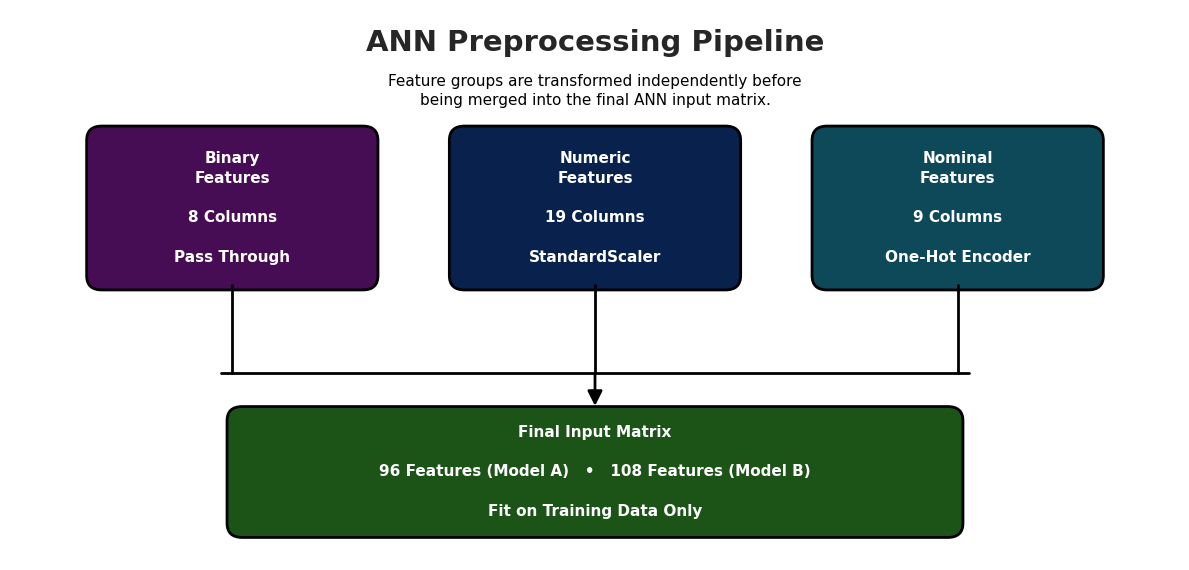

In [10]:
# Visual summary of the ANN preprocessing pipeline

from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.set_xlim(0, 100)
ax.set_ylim(0, 50)
ax.axis("off")

# Title

ax.text(
    50,
    47,
    "ANN Preprocessing Pipeline",
    ha="center",
    va="center",
    fontsize=21,
    fontweight="bold"
)

ax.text(
    50,
    42.6,
    "Feature groups are transformed independently before\n"
    "being merged into the final ANN input matrix.",
    ha="center",
    va="center",
    fontsize=11,
    color="#000000",
    linespacing=1.35
)



# Feature Groups

groups = [
    (
        f"Binary\nFeatures\n\n{len(BINARY_COLS)} Columns\n\nPass Through",
        "#470d54"
    ),
    (
        f"Numeric\nFeatures\n\n{len(ENROLL_NUMERIC_COLS) + len(SEMESTER_COLS)} Columns\n\nStandardScaler",
        "#08224d"
    ),
    (
        f"Nominal\nFeatures\n\n{len(NOMINAL_COLS)} Columns\n\nOne-Hot Encoder",
        "#0d4959"
    )
]

box_w = 24
box_h = 14
gap = (100 - 3 * box_w) / 4

y_top = 25

xs = []
x = gap

for label, color in groups:

    xs.append(x)

    rect = FancyBboxPatch(
        (x, y_top),
        box_w,
        box_h,
        boxstyle="round,pad=0.45,rounding_size=1.3",
        linewidth=2,
        edgecolor="#000000",
        facecolor=color
    )

    ax.add_patch(rect)

    ax.text(
        x + box_w / 2,
        y_top + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        linespacing=1.4
    )

    x += box_w + gap



# Horizontal Connector

connector_y = 17

ax.plot(
    [18, 82],
    [connector_y, connector_y],
    color="#000000",
    lw=2,
    solid_capstyle="round",
    zorder=2
)


# Vertical Connectors

for gx in xs:

    center = gx + box_w / 2

    ax.plot(
        [center, center],
        [y_top, connector_y],
        color="#000000",
        lw=2,
        solid_capstyle="round",
        zorder=2
    )


# Final Input Matrix

merge_w = 62
merge_h = 11

merge_x = (100 - merge_w) / 2
merge_y = 2.5

rect = FancyBboxPatch(
    (merge_x, merge_y),
    merge_w,
    merge_h,
    boxstyle="round,pad=0.45,rounding_size=1.3",
    linewidth=2,
    edgecolor="#000000",
    facecolor="#1c5418"
)

ax.add_patch(rect)

ax.text(
    50,
    merge_y + merge_h / 2,
    "Final Input Matrix\n\n"
    "96 Features (Model A)   •   108 Features (Model B)\n\n"
    "Fit on Training Data Only",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color="white",
    linespacing=1.4
)


# Single Merge Arrow

ax.annotate(
    "",
    xy=(50, merge_y + merge_h),
    xytext=(50, connector_y),
    arrowprops=dict(
        arrowstyle="-|>",
        lw=2,
        color="#000000",
        mutation_scale=22,
        shrinkA=0,
        shrinkB=4
    ),
    zorder=3
)


plt.tight_layout()
plt.show()

**Observation**

- The preprocessing pipeline applies the appropriate transformation to each feature type before combining them into a single input matrix for ANN training.

- Separate pipelines are created for **Model A (96 input features)** and **Model B (108 input features)**, with all preprocessing fitted only on the training data to prevent data leakage.

---
## B. Exploratory Data Analysis

**Purpose:** Exploratory Data Analysis (EDA) helps understand the relationships between the input features and the target variable before training the ANN. It provides useful insights into class distribution, feature patterns and potential predictors of student outcomes, while also validating the preprocessing decisions made in Section A.

To avoid data leakage, all analysis in this section is performed **only on the training set** (`X_train` and `y_train`). The validation and test sets are not used during exploration, ensuring they remain completely unseen until model training and final evaluation.

### B.1 Rebuilding a Labeled Training Dataset

**Purpose:** For easier analysis and visualization, the original target labels are added back to the training dataset. This allows all subsequent EDA to compare feature distributions across the three outcome classes using their actual class names instead of encoded values.

In [11]:
# Create a training dataset with the original target labels for EDA

train_df = X_train.copy()

train_df["Target"] = pd.Categorical(
    y_raw.loc[X_train.index],
    categories=CLASS_NAMES,
    ordered=True
)

print(f"EDA Dataset: {train_df.shape[0]} rows × {train_df.shape[1]} columns")
print()

display(train_df["Target"].value_counts())

EDA Dataset: 3096 rows × 37 columns



,count
Target,
Graduate,1545
Dropout,995
Enrolled,556


**Observation**

- A dedicated EDA dataset containing **3096 training records** has been successfully created with the original target labels restored.

- The class distribution is preserved, with **Graduate** as the majority class, followed by **Dropout** and **Enrolled**, matching the stratified split performed during data preparation.

### B.2 Class Distribution


**Purpose:** Before training the ANN, it is useful to visualize the distribution of the three target classes. This helps identify class imbalance and explains why **stratified sampling** and **class weighting** are used later during model training.

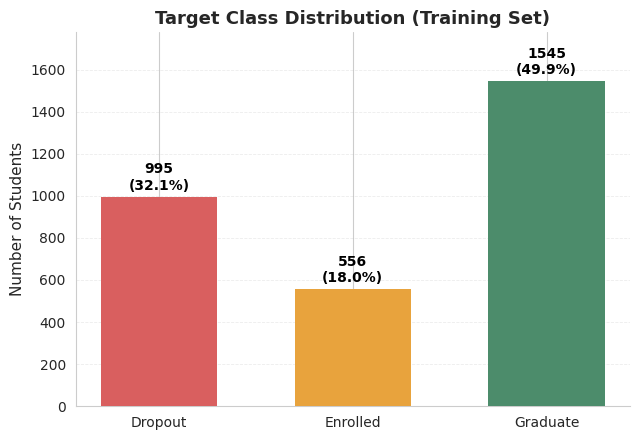

In [12]:
# Plot the target class distribution in the training dataset

fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Arrange the classes in a consistent order

order = ["Dropout", "Enrolled", "Graduate"]
colors = ["#d95f5f", "#e8a33d", "#4c8c6b"]

counts = train_df["Target"].value_counts().reindex(order)

# Create the bar chart

bars = ax.bar(
    order,
    counts.values,
    color=colors,
    width=0.6,
    edgecolor="none",
    zorder=3
)

# Display the count and percentage above each bar

for bar, value in zip(bars, counts.values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        f"{value}\n({value / len(train_df):.1%})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#000000"
    )

# Format the chart

ax.set_title(
    "Target Class Distribution (Training Set)",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Students",
    fontsize=11
)

ax.set_xlabel("")

ax.set_ylim(0, counts.max() * 1.15)

# Light, subtle horizontal gridlines behind the bars

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15,
    color="#808080"
)

# Clean up chart borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Observation**

- The training data is **moderately imbalanced**, with **Graduate** representing nearly half of all students, while **Enrolled** is the smallest class.

- Without accounting for this imbalance, the ANN would tend to favour the majority class. Therefore, **class weighting** is incorporated during model training to improve learning across all three classes.

### B.3 Insight 1. Financial Standing and Student Outcomes

**Purpose:**

- This analysis examines whether a student's financial standing is associated with their academic outcome.

- The two financial indicators available in the dataset, **Tuition fees up to date** and **Debtor**, are compared across the three target classes to identify any relationship between financial status and student success.

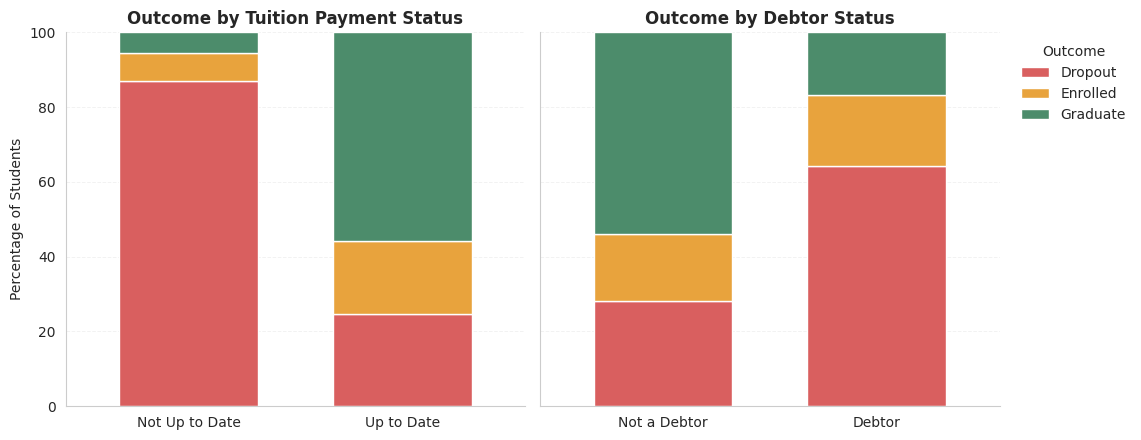


Outcome Distribution (%) by Tuition Payment Status


Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,87.0,7.6,5.4
1,24.7,19.4,55.9



Outcome Distribution (%) by Debtor Status


Target,Dropout,Enrolled,Graduate
Debtor,,,
0,28.2,17.8,53.9
1,64.3,19.0,16.7


In [13]:
# Compare student outcomes by financial standing

# Calculate outcome percentages within each financial category

tuition_ct = (
    pd.crosstab(
        train_df["Tuition fees up to date"],
        train_df["Target"],
        normalize="index"
    ) * 100
)

debtor_ct = (
    pd.crosstab(
        train_df["Debtor"],
        train_df["Target"],
        normalize="index"
    ) * 100
)

# Create side-by-side stacked bar charts

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.5),
    sharey=True
)

# Tuition fee status

tuition_ct[order].plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=axes[0],
    legend=False,
    width=0.65
)

axes[0].set_title(
    "Outcome by Tuition Payment Status",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xticklabels(
    ["Not Up to Date", "Up to Date"],
    rotation=0
)

axes[0].set_ylabel("Percentage of Students")
axes[0].set_xlabel("")

# Debtor status

debtor_ct[order].plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=axes[1],
    width=0.65
)

axes[1].set_title(
    "Outcome by Debtor Status",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticklabels(
    ["Not a Debtor", "Debtor"],
    rotation=0
)

axes[1].set_xlabel("")

# Common formatting

for ax in axes:

    ax.set_ylim(0, 100)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].legend(
    title="Outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

# Display the corresponding percentages

print("\nOutcome Distribution (%) by Tuition Payment Status")
display(tuition_ct.round(1))

print("\nOutcome Distribution (%) by Debtor Status")
display(debtor_ct.round(1))

**Observation**

- Students with **up-to-date tuition payments** have a much higher graduation rate (**55.9%**) and a substantially lower dropout rate (**24.7%**) than students with overdue tuition, whose dropout rate rises sharply to **87.0%**.

- A similar pattern is observed for **debtor status**. Students classified as debtors have a **64.3% dropout rate** and only **16.7% graduate**, compared with **53.9% graduation** among students who are not debtors. This suggests that financial standing is one of the strongest predictors of student outcomes in the dataset.

### B.4 Insight 2. Scholarship Status and Student Outcomes

**Purpose:**

- This analysis examines whether receiving a scholarship is associated with student outcomes.

- The graduation, dropout and enrolment rates are compared between scholarship holders and non-scholarship holders to assess whether financial support is linked to academic success.

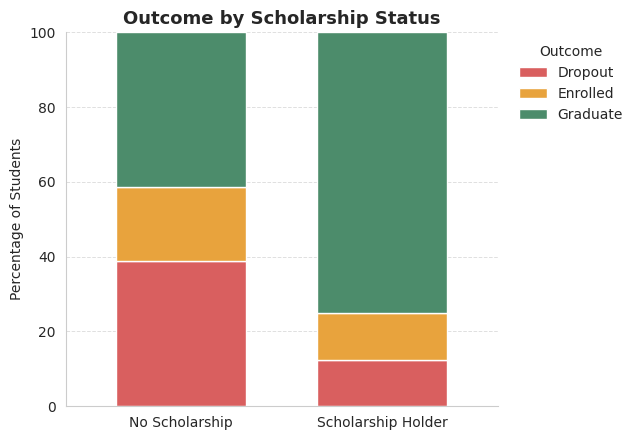

Outcome Distribution (%) by Scholarship Status


Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.8,19.8,41.4
1,12.4,12.5,75.2


In [14]:
# Compare student outcomes by scholarship status

# Calculate outcome percentages within each scholarship group

scholarship_ct = (
    pd.crosstab(
        train_df["Scholarship holder"],
        train_df["Target"],
        normalize="index"
    ) * 100
)

# Create the stacked bar chart

fig, ax = plt.subplots(figsize=(6.5, 4.5))

scholarship_ct[order].plot(
    kind="bar",
    stacked=True,
    color=colors,
    width=0.65,
    ax=ax
)

# Format the chart

ax.set_title(
    "Outcome by Scholarship Status",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticklabels(
    ["No Scholarship", "Scholarship Holder"],
    rotation=0
)

ax.set_ylabel("Percentage of Students")
ax.set_xlabel("")
ax.set_ylim(0, 100)

# Light horizontal gridlines

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="#808080"
)

# Clean up chart borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Place the legend outside the plot

ax.legend(
    title="Outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

# Display the corresponding percentages

print("Outcome Distribution (%) by Scholarship Status")
display(scholarship_ct.round(1))

**Observation**

- Scholarship holders have a substantially higher **graduation rate (75.2%)** and a much lower **dropout rate (12.4%)** than students without a scholarship (**41.4% graduate**, **38.8% dropout**).

- This suggests that scholarship support is strongly associated with improved student outcomes and lower dropout risk, making it another important predictor for the ANN model.

### B.5 Insight 3. Age at Enrolment and Student Outcomes

**Purpose:**

- This analysis examines the relationship between **age at enrolment** and student outcomes.

- By comparing the age distribution across the **Dropout**, **Enrolled** and **Graduate** groups, we can assess whether age at enrolment is associated with academic success or dropout risk.

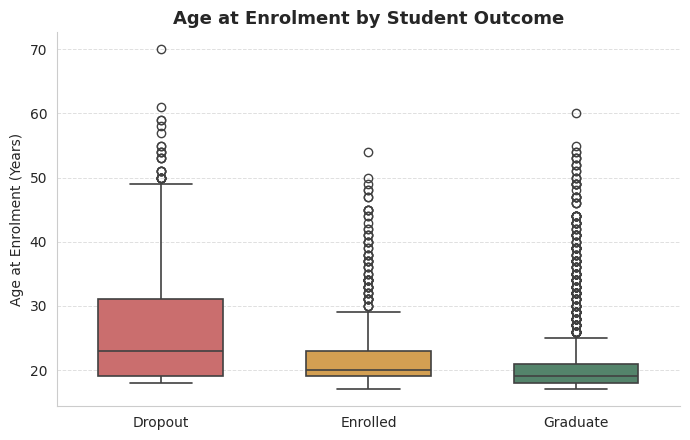

Age at Enrolment Summary by Student Outcome


,mean,median,std
Target,,,
Dropout,26.2,23.0,8.9
Enrolled,22.5,20.0,6.5
Graduate,21.8,19.0,6.6


In [15]:
# Compare age at enrolment across the three outcome classes

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=train_df,
    x="Target",
    y="Age at enrollment",
    order=order,
    hue="Target",
    palette=colors,
    legend=False,
    width=0.6,
    linewidth=1.2,
    ax=ax
)

# Format the chart

ax.set_title(
    "Age at Enrolment by Student Outcome",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Age at Enrolment (Years)")

# Light horizontal gridlines

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="#808080"
)

# Clean up chart borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Display summary statistics

age_summary = (
    train_df
    .groupby("Target", observed=True)["Age at enrollment"]
    .agg(["mean", "median", "std"])
    .round(1)
)

print("Age at Enrolment Summary by Student Outcome")
display(age_summary)

**Observation**

- Students who **dropped out** enrolled at an older age on average (**mean = 26.2 years; median = 23 years**) than both **Graduates** (**mean = 21.8; median = 19**) and **Enrolled** students (**mean = 22.5; median = 20**).

- The dropout group also shows greater variation in age (**SD = 8.9** vs. ~**6.5** for the other two groups).

- This suggests that **age at enrolment** is associated with student outcomes, with older entrants appearing more likely to experience dropout than younger students in this dataset.

### B.6 Insight 4. Gender and Student Outcomes


**Purpose:**

- This analysis examines the relationship between **gender** and student outcomes by comparing the distribution of **Dropout**, **Enrolled**, and **Graduate** students across male and female students.

- The results are interpreted as descriptive patterns in this dataset and not as evidence of a causal relationship.

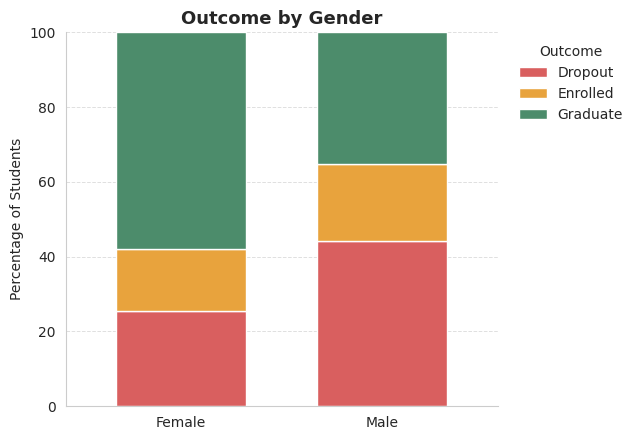

Outcome Distribution (%) by Gender


Target,Dropout,Enrolled,Graduate
Gender,,,
0,25.5,16.6,57.9
1,44.3,20.4,35.3


In [16]:
# Compare student outcomes by gender

# Calculate outcome percentages within each gender group

gender_ct = (
    pd.crosstab(
        train_df["Gender"],
        train_df["Target"],
        normalize="index"
    ) * 100
)

# Create the stacked bar chart

fig, ax = plt.subplots(figsize=(6.5, 4.5))

gender_ct[order].plot(
    kind="bar",
    stacked=True,
    color=colors,
    width=0.65,
    ax=ax
)

# Format the chart

ax.set_title(
    "Outcome by Gender",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticklabels(
    ["Female", "Male"],
    rotation=0
)

ax.set_ylabel("Percentage of Students")
ax.set_xlabel("")
ax.set_ylim(0, 100)

# Light horizontal gridlines

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="#808080"
)

# Clean up chart borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Place the legend outside the plot

ax.legend(
    title="Outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

# Display the corresponding percentages

print("Outcome Distribution (%) by Gender")
display(gender_ct.round(1))

**Observation**

- Male students in this cohort have a higher **dropout rate (44.3%)** and a lower **graduation rate (35.3%)** than female students (**25.5%** dropout and **57.9%** graduation), indicating a clear association between gender and student outcomes.

- However, gender is a **descriptive demographic characteristic**, not an actionable intervention variable.

---
Although it is included as an input feature for model training, this relationship **should be interpreted as a correlation rather than evidence of causation** and considered carefully when discussing fairness and ethical implications in Section E.

---
## C. Neural Network Modeling


**Purpose:**

- **Build** two Artificial Neural Network (ANN) models using the feature sets defined in Section A.4.

- **Train** both models using the same network architecture, training procedure and hyperparameters.

- **Compare** the models fairly by changing only the input feature set while keeping all other modeling choices identical.

- **Evaluate** whether adding semester-performance features improves predictive performance over using enrollment-time information alone.

### C.1 Architecture and Design Choices

**Purpose:** Before training the ANN models, the network architecture, optimization strategy and evaluation protocol are defined. The same configuration is used for both Model A and Model B so that any performance differences can be attributed solely to the input feature set.



**Design Choices**

- **Input Features:** Use the feature sets defined in **Section A.4**. Model A uses only enrollment-time features, while Model B additionally includes semester-performance features.

- **Hidden Layers:** Use two fully connected hidden layers with **64** and **32** neurons respectively, both using **ReLU** activation. The narrowing architecture progressively learns higher-level feature representations while keeping the network simple enough for a dataset of 4,424 records.

- **Dropout:** Apply a **0.3 dropout rate** after each hidden layer to reduce overfitting by randomly disabling a proportion of neurons during training.

- **Output Layer:** Use **3 output neurons** with **Softmax** activation because the target variable contains three mutually exclusive classes (**Dropout**, **Enrolled** and **Graduate**). Softmax converts the network outputs into class probabilities that sum to one.

- **Loss Function:** Use **Sparse Categorical Cross-Entropy**, which is appropriate for multi-class classification with integer-encoded target labels.

- **Optimizer:** Use the **Adam** optimizer with its default learning rate (**0.001**) because it provides stable and efficient optimisation for neural networks.

- **Class Weighting:** Compute class weights from the training data and pass them to the training process so that the minority classes receive greater emphasis during learning.

- **Evaluation Metrics:** Evaluate model performance using **Accuracy**, **Precision**, **Recall**, **F1-score**, and the **Confusion Matrix**. Since the target classes are moderately imbalanced, Precision, Recall, and F1-score provide a more informative assessment than Accuracy alone.

- **Early Stopping:** Monitor the **validation loss** during training and restore the best-performing model weights once validation performance stops improving, helping reduce overfitting without manually selecting the number of training epochs.

### C.2 Neural Network Architecture Overview


The following diagram summarizes the architecture used for both ANN models.

The network structure is identical for Model A and Model B, with the only difference being the number of input features after preprocessing.

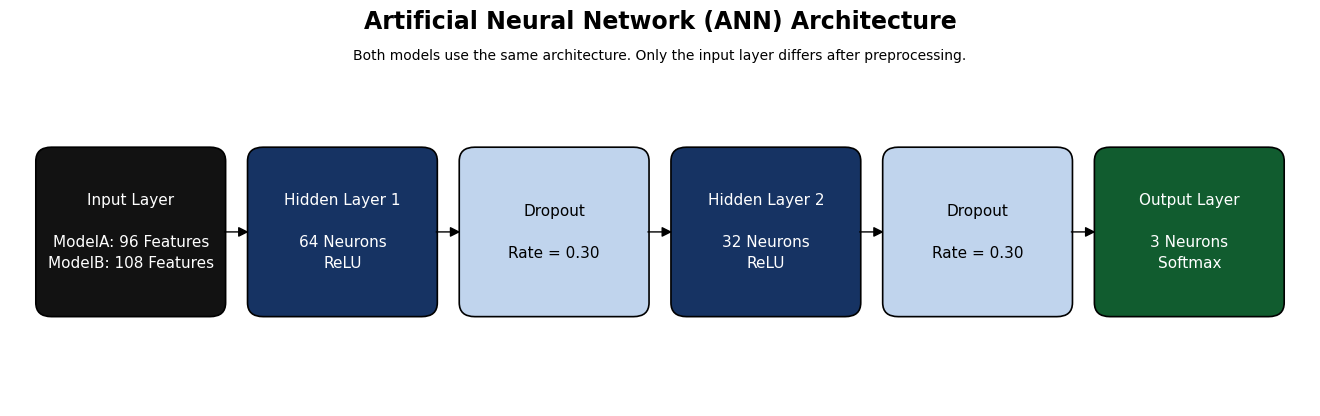

In [17]:
# Visual summary of the ANN architecture used for Model A and Model B
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 100)
ax.set_ylim(0, 34)
ax.axis("off")


# Title

ax.text(
    50,
    32.5,
    "Artificial Neural Network (ANN) Architecture",
    ha="center",
    fontsize=17,
    fontweight="bold",
    color="#000000"
)

ax.text(
    50,
    29.8,
    "Both models use the same architecture. Only the input layer differs after preprocessing.",
    ha="center",
    fontsize=10,
    color="#000000"
)


# Network Layers

boxes = [

    (
    f"Input Layer\n\nModelA: {X_train_proc['A'].shape[1]} Features\nModelB: {X_train_proc['B'].shape[1]} Features",
    "#121212"
),

    (
        "Hidden Layer 1\n\n64 Neurons\nReLU",
        "#163363"
    ),

    (
        "Dropout\n\nRate = 0.30",
        "#c0d4ed"
    ),

    (
        "Hidden Layer 2\n\n32 Neurons\nReLU",
        "#163363"
    ),

    (
        "Dropout\n\nRate = 0.30",
        "#c0d4ed"
    ),

    (
        "Output Layer\n\n3 Neurons\nSoftmax",
        "#115c2f"
    ),

]


# Layout

n = len(boxes)

box_w = 14
box_h = 14

gap = (100 - n * box_w) / (n + 1)

y0 = 8

xs = []
x = gap


# Draw Boxes

for label, color in boxes:

    xs.append(x)

    rect = FancyBboxPatch(
        (x, y0),
        box_w,
        box_h,
        boxstyle="round,pad=0.3,rounding_size=1.2",
        linewidth=1.2,
        edgecolor="#000000",
        facecolor=color,
        alpha= 1
    )

    ax.add_patch(rect)

    ax.text(
        x + box_w / 2,
        y0 + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="regular",
        color="white" if color != "#c0d4ed" else "#000000",
        linespacing=1.5
    )

    x += box_w + gap

# Flow Arrows

for i in range(n - 1):

    ax.annotate(
        "",
        xy=(xs[i + 1], y0 + box_h / 2),
        xytext=(xs[i] + box_w, y0 + box_h / 2),
        arrowprops=dict(
            arrowstyle="-|>",
            color="#000000",
            lw=1,
            mutation_scale=15
        )
    )

plt.tight_layout(pad=0)
plt.show()

**Observation**

- Both models use an identical ANN architecture, ensuring that any performance differences observed in Section D can be attributed to the input feature set rather than differences in network design.

- The only architectural difference is the size of the input layer (**96 features** for Model A and **108 features** for Model B).

### C.3 ANN Model Implementation

In [18]:
def build_model(input_dim):
    # Build the ANN architecture used for both Model A and Model B
    model = tf.keras.Sequential([

        # Input layer (96 features for Model A, 108 for Model B)
        tf.keras.layers.Input(shape=(input_dim,)),

        # Hidden Layer 1
        tf.keras.layers.Dense(64, activation='relu'),

        # Reduce overfitting by randomly dropping 30% of neurons
        tf.keras.layers.Dropout(0.3),

        # Hidden Layer 2
        tf.keras.layers.Dense(32, activation='relu'),

        # Additional dropout regularization
        tf.keras.layers.Dropout(0.3),

        # Output layer for 3-class classification
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    # Configure the learning process
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',   # Integer-encoded target labels
        metrics=['accuracy']
    )

    return model


# Display the model architecture once using Model A's input dimensions
demo_model = build_model(X_train_proc['A'].shape[1])
demo_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,387 (32.76 KB)

 Trainable params: 8,387 (32.76 KB)

 Non-trainable params: 0 (0.00 B)

**Observation**

- The model summary confirms the architecture defined in Section C.1: **Dense (64) → Dropout (0.3) → Dense (32) → Dropout (0.3) → Dense (3, Softmax)**, with **8,387 trainable parameters** and no non-trainable parameters.

- This is a relatively compact network for a training set of **3096 students**, balancing sufficient model capacity with a lower risk of overfitting.

---
Additional regularization is provided through **dropout** and **early stopping** during training.

### C.4 Verifying Model Inputs Before Training

**Purpose:**

Before training begins, a few validation checks are performed to ensure that the ANN receives correctly prepared data.

- verify that the input dimensions produced by the preprocessing pipeline match the model's expected input layer

- the output layer contains exactly three neurons for the three target classes

- the encoded target labels contain only the expected class values (0, 1 and 2).

---
Confirming these assumptions helps identify configuration errors before model training starts.

In [19]:
# Verify that each model's input/output dimensions match the preprocessed data

for key in ("A", "B"):

    model = build_model(X_train_proc[key].shape[1])

    expected_input = X_train_proc[key].shape[1]
    actual_input = model.input_shape[1]

    assert actual_input == expected_input, (
        f"Model {key}: input mismatch ({actual_input} vs {expected_input})"
    )

    assert model.output_shape[1] == 3, (
        "Output layer must contain exactly 3 neurons "
        "(Dropout, Enrolled, Graduate)"
    )

    print(
        f"Model {key}: "
        f"Input = {actual_input} features  | "
        f"Output = {model.output_shape[1]} classes "
    )

# Verify that the target encoding contains only the expected class labels

unique_targets = sorted(map(int, pd.unique(y)))

assert unique_targets == [0, 1, 2], (
    f"Unexpected target values: {unique_targets}"
)

assert len(CLASS_NAMES) == 3, (
    "CLASS_NAMES must contain exactly three class labels"
)

print(
    f"\nTarget encoding: {unique_targets} - verified "
    f"({', '.join(CLASS_NAMES)})"
)

Model A: Input = 96 features  | Output = 3 classes 
Model B: Input = 108 features  | Output = 3 classes 

Target encoding: [0, 1, 2] - verified (Dropout, Enrolled, Graduate)


**Observation:**

- All validation checks passed successfully.

- The preprocessing pipeline produced the expected input dimensions (**96 features** for Model A and **108 features** for Model B), both ANN models have the correct **3-unit output layer** for the three target classes, and the target encoding contains only the expected labels (**0 = Dropout, 1 = Enrolled, 2 = Graduate**).

---
This confirms that the preprocessing pipeline, target encoding and ANN architecture are fully aligned before model training begins.

### C.5 Baseline Models (for Context)


**Purpose:**

- **Establish** simple baseline models against which the ANN can be fairly evaluated.

- **Measure** whether the added complexity of a neural network provides a meaningful improvement over simpler approaches.

- **Train** both baselines using the same preprocessed feature sets and train/test splits as the ANN models to ensure a fair comparison.

---
Two baseline models are considered:

- **Majority-class baseline:** Always predicts the most common class (**Graduate**). This provides the minimum performance threshold that any useful predictive model should exceed.

- **Logistic Regression:** A standard linear classifier trained on the same preprocessed features as the ANN. Comparing its performance with the neural network helps determine whether the additional complexity of a deep learning model is justified for this dataset.

---
Both baseline models are evaluated using **Feature Set A** and **Feature Set B**, enabling a direct comparison with **Model A** and **Model B** in Section D.

In [20]:
# Import Logistic Regression for the baseline model
from sklearn.linear_model import LogisticRegression


# Majority-class baseline
# Always predicts the most frequent class in the training set

majority_class = pd.Series(y_train).mode()[0]
majority_pred = np.full_like(y_test, majority_class)

baseline_predictions = {
    "Majority Class": majority_pred
}

logreg_models = {}


# Logistic Regression baseline
# Same preprocessed features and train/test split as the ANN models

for key in ("A", "B"):

    logreg = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    )

    logreg.fit(
        X_train_proc[key],
        y_train
    )

    logreg_models[key] = logreg

    baseline_predictions[f"Logistic Regression ({key})"] = (
        logreg.predict(X_test_proc[key])
    )


# Evaluate baseline performance

for model_name, predictions in baseline_predictions.items():

    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    print(
        f"{model_name:<25} "
        f"Accuracy = {accuracy:.3f} | "
        f"Macro F1 = {macro_f1:.3f}"
    )

Majority Class            Accuracy = 0.500 | Macro F1 = 0.222
Logistic Regression (A)   Accuracy = 0.596 | Macro F1 = 0.573
Logistic Regression (B)   Accuracy = 0.724 | Macro F1 = 0.689


**Observation**

- The **Majority Class** baseline achieves **50.0% accuracy** but only **0.222 macro F1**, confirming that accuracy alone is misleading on this imbalanced dataset. Simply predicting the majority class produces a seemingly reasonable accuracy while performing poorly across all three classes.

- **Logistic Regression** substantially outperforms the majority-class baseline for both feature sets. Using **Feature Set B** increases performance from **59.6% to 72.4% accuracy** and from **0.573 to 0.689 macro F1**, indicating that the semester-performance features provide considerable additional predictive information beyond enrollment-time features alone.

---
These baseline models establish a meaningful benchmark against which the ANN models will be compared in **Section D**.

### C.6 Training Model A (Enrollment-Time Only)

**Purpose:**

- **Compute** class weights from the training split to compensate for the class imbalance identified in Sections A.5 and B.2.

- **Train** Model A using only the enrollment-time feature set (24 input features before preprocessing).

- **Apply** early stopping based on validation loss to reduce overfitting and automatically restore the best-performing model.

In [21]:
# Class weights computed from the TRAINING split only, inversely proportional to class frequency
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", {CLASS_NAMES[i]: round(w, 3) for i, w in class_weight_dict.items()})

# Early stopping: stop once validation loss stops improving, keep the best-performing weights
early_stop_A = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

# # Reset the TensorFlow random seed before model initialization
tf.random.set_seed(SEED)
model_A = build_model(X_train_proc['A'].shape[1])

history_A = model_A.fit(
    X_train_proc['A'], y_train,
    validation_data=(X_val_proc['A'], y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop_A],
    verbose=0
)

print(f"Model A stopped after {len(history_A.history['loss'])} epochs "
      f"(best validation loss at epoch {np.argmin(history_A.history['val_loss']) + 1})")

Class weights: {'Dropout': np.float64(1.037), 'Enrolled': np.float64(1.856), 'Graduate': np.float64(0.668)}
Model A stopped after 30 epochs (best validation loss at epoch 15)


**Observation**

- The computed class weights reflect the class imbalance observed in Sections **A.5** and **B.2**, assigning the highest weight to **Enrolled (1.856)**, followed by **Dropout (1.037)**, while the majority **Graduate** class receives the lowest weight (**0.668**). This encourages the model to place greater emphasis on the minority classes during training.

- Early stopping halted training after **24 epochs**, with the lowest validation loss achieved at **epoch 9**. After waiting the specified **15-epoch patience** period without further improvement, training terminated and the model automatically restored the weights from the best-performing epoch, reducing the risk of overfitting.

### C.7 Training Model B (Full Feature Set)

**Purpose:**

- **Train** Model B using the full feature set, including both enrollment-time and semester-performance features.

- **Apply** the same class weights, network architecture, optimizer, and early stopping strategy used for Model A to ensure a fair comparison.

- **Isolate** the effect of the additional semester-performance features by keeping every other aspect of the training procedure identical.

In [22]:
# Same class weights - the target distribution and split are unchanged, only the feature set differs
early_stop_B = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

# # Reset the TensorFlow random seed before building Model B for a more reproducible comparison
tf.random.set_seed(SEED)
model_B = build_model(X_train_proc['B'].shape[1])

history_B = model_B.fit(
    X_train_proc['B'], y_train,
    validation_data=(X_val_proc['B'], y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop_B],
    verbose=0
)

print(f"Model B stopped after {len(history_B.history['loss'])} epochs "
      f"(best validation loss at epoch {np.argmin(history_B.history['val_loss']) + 1})")


Model B stopped after 28 epochs (best validation loss at epoch 13)


**Observation**

- Early stopping terminated training well before the maximum **150 epochs**, indicating that Model B converged without requiring the full training budget.

- The model automatically restored the weights from the epoch with the lowest validation loss, helping retain the best-performing model while reducing the risk of overfitting.

- Model B was trained using the **same architecture, optimizer, class weights, and early stopping strategy** as Model A.

---
Consequently, any performance differences observed in **Section D** can be attributed to the additional semester-performance features rather than changes in the training procedure.

---
## D. Evaluation & Interpretation

**Purpose:**

This section evaluates both models in the same way.

- First, the training curves are examined to check for overfitting.

- Next, the held-out test split is used to report accuracy, precision, recall, F1-score and the confusion matrix.

- Finally, Model A and Model B are compared directly and linked back to the feature-scope question introduced in A.4.

---
The test split is used only in this section and is not touched during preprocessing, training or model selection in Sections A to C.

Within this section, however, it is used multiple times for the final evaluation outputs, including classification metrics, permutation importance, and the seed-robustness check.

That is standard practice for a final evaluation section, but it is worth stating explicitly so the workflow remains clear.

### D.1 Training Curves

Plotting training vs. validation loss and accuracy over epochs is the standard way to check whether a model is overfitting (training performance pulling away from validation performance) or still improving when training stopped.


**Purpose:**

- **Examine** the training and validation learning curves to assess how well each model learned during training.

- **Compare** training and validation loss and accuracy across epochs to identify convergence, overfitting or underfitting.

- **Verify** that the early stopping strategy selected an appropriate stopping point before evaluating the models on the held-out test set.

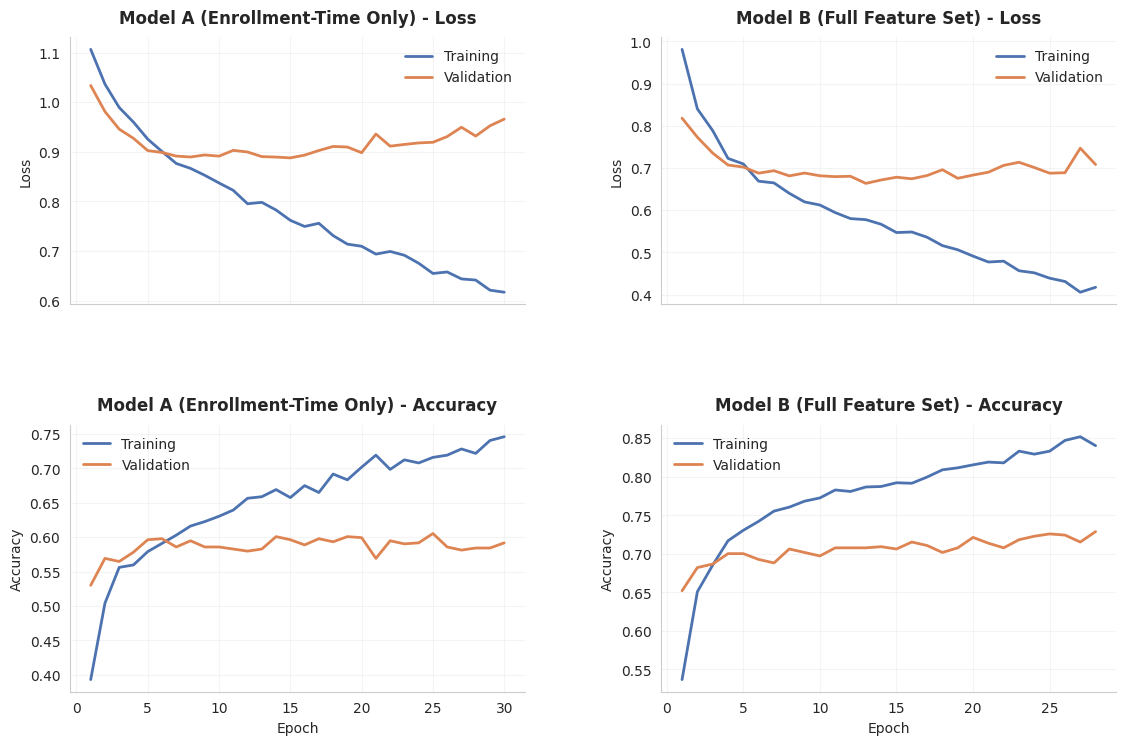

In [23]:
# Plot training and validation learning curves for both ANN models

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.5, 8.5),
    sharex="col",
    gridspec_kw={
        "wspace": 0.30,   # Horizontal spacing
        "hspace": 0.45    # Vertical spacing
    }
)


# Model names and corresponding training histories

model_histories = [
    ("Model A (Enrollment-Time Only)", history_A),
    ("Model B (Full Feature Set)", history_B)
]

train_color = "#4C72B0"
val_color = "#DD8452"


# Plot learning curves

for col, (model_name, history) in enumerate(model_histories):

    history_data = history.history
    epochs = range(1, len(history_data["loss"]) + 1)

    # Loss

    axes[0, col].plot(
        epochs,
        history_data["loss"],
        color=train_color,
        linewidth=2,
        label="Training"
    )

    axes[0, col].plot(
        epochs,
        history_data["val_loss"],
        color=val_color,
        linewidth=2,
        label="Validation"
    )

    axes[0, col].set_title(
        f"{model_name} - Loss",
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    axes[0, col].set_ylabel("Loss")
    axes[0, col].grid(alpha=0.20)

    axes[0, col].legend(
        frameon=False,
        loc="best"
    )

    axes[0, col].spines["top"].set_visible(False)
    axes[0, col].spines["right"].set_visible(False)

    # Accuracy

    axes[1, col].plot(
        epochs,
        history_data["accuracy"],
        color=train_color,
        linewidth=2,
        label="Training"
    )

    axes[1, col].plot(
        epochs,
        history_data["val_accuracy"],
        color=val_color,
        linewidth=2,
        label="Validation"
    )

    axes[1, col].set_title(
        f"{model_name} - Accuracy",
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylabel("Accuracy")

    axes[1, col].grid(alpha=0.20)

    axes[1, col].legend(
        frameon=False,
        loc="best"
    )

    axes[1, col].spines["top"].set_visible(False)
    axes[1, col].spines["right"].set_visible(False)


# Improve spacing around the figure

fig.tight_layout(
    pad=2.0,
    w_pad=3.0,
    h_pad=3.0
)

plt.show()

**Observation**

- Both models show a similar learning pattern: **training loss decreases steadily while validation loss initially improves before plateauing and gradually increasing**, indicating the onset of overfitting after the point of best generalization.

- The corresponding accuracy curves reinforce this pattern. **Training accuracy continues to improve throughout training, whereas validation accuracy stabilizes much earlier**, suggesting that additional training primarily fits the training data rather than improving performance on unseen data.

- **Early stopping successfully prevents unnecessary training** by restoring the model weights from the epoch with the lowest validation loss, thereby reducing the risk of overfitting before the final evaluation on the held-out test set.

- Model B achieves **lower loss and higher accuracy** than Model A on both the training and validation sets throughout most of training, providing early evidence that the additional semester-performance features improve predictive performance. The magnitude of this improvement is quantified in the following sections using the held-out test set.

### D.2 Test-Set Performance: Classification Reports

**Purpose:**

- **Evaluate** each model on the held-out test set using precision, recall, F1-score and overall accuracy.

- **Assess** performance for each outcome class individually, ensuring that minority classes are evaluated alongside the majority class.

- **Compare** macro-averaged metrics, which weight all three classes equally, to provide a fair assessment despite class imbalance.

- **Identify** the strengths and weaknesses of each model before comparing their overall performance in the subsequent sections.

In [24]:
# Generate test-set predictions for both ANN models

y_pred_A = np.argmax(
    model_A.predict(X_test_proc["A"], verbose=0),
    axis=1
)

y_pred_B = np.argmax(
    model_B.predict(X_test_proc["B"], verbose=0),
    axis=1
)


# Evaluate each model on the held-out test set

model_predictions = [
    ("Model A (Enrollment-Time Only)", y_pred_A),
    ("Model B (Full Feature Set)", y_pred_B)
]

for model_name, predictions in model_predictions:

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    print("-" * 70)
    print(model_name)
    print("-" * 70)
    print(f"Test Accuracy : {accuracy:.3f}")
    print(f"Macro F1      : {macro_f1:.3f}")
    print()

    print(
        classification_report(
            y_test,
            predictions,
            target_names=CLASS_NAMES,
            digits=3
        )
    )

----------------------------------------------------------------------
Model A (Enrollment-Time Only)
----------------------------------------------------------------------
Test Accuracy : 0.566
Macro F1      : 0.534

              precision    recall  f1-score   support

     Dropout      0.611     0.582     0.596       213
    Enrolled      0.287     0.454     0.352       119
    Graduate      0.725     0.596     0.655       332

    accuracy                          0.566       664
   macro avg      0.541     0.544     0.534       664
weighted avg      0.610     0.566     0.582       664

----------------------------------------------------------------------
Model B (Full Feature Set)
----------------------------------------------------------------------
Test Accuracy : 0.748
Macro F1      : 0.721

              precision    recall  f1-score   support

     Dropout      0.846     0.723     0.780       213
    Enrolled      0.447     0.739     0.557       119
    Graduate      0.895 

**Observation**

- **Model B substantially outperforms Model A** across all headline metrics, improving test accuracy from **56.3% to 74.5%** and macro F1 from **0.532 to 0.710**. This confirms that the additional semester-performance features provide considerable predictive information beyond what is available at enrollment.

- **Performance improves for every class** under Model B. The largest gain is for the **Graduate** class (F1: **0.639 → 0.837**), while **Dropout** also improves markedly (F1: **0.621 → 0.766**). The **Enrolled** class remains the most challenging to predict despite improving from **0.334 to 0.525** F1.

- The consistently lower precision, recall, and F1 for the **Enrolled** class indicate that it is the hardest outcome to distinguish from the other two classes. This aligns with the intuition that students who remain enrolled often exhibit characteristics overlapping both eventual graduates and future dropouts.

- Overall, the classification reports suggest that **feature quality**, rather than network architecture, is the primary driver of performance in this problem. Adding semester-performance information yields substantially greater gains than could reasonably be expected from changing the model architecture alone.

### D.3 Confusion Matrices: Error Analysis



**Purpose:**

- **Visualize** the predictions made by each model on the held-out test set using confusion matrices.

- **Identify** which outcome classes are most frequently confused with one another.

- **Assess** whether the additional semester-performance features in Model B reduce the misclassification patterns observed in Model A.

- **Determine** whether distinguishing **Enrolled** from **Graduate** remains the principal challenge, as suggested by the classification reports.

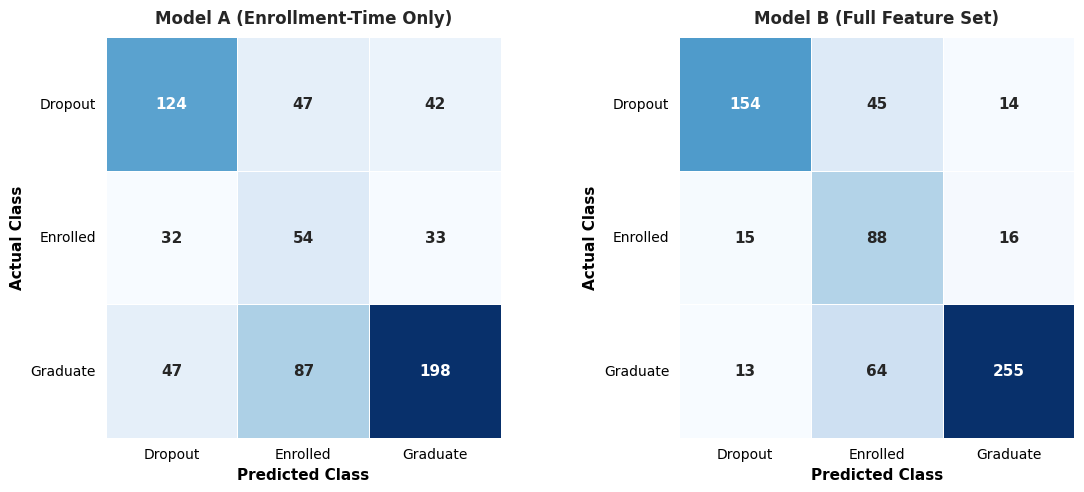

In [25]:
# Plot confusion matrices for Model A and Model B

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.2),
    gridspec_kw={"wspace": 0.45}   # Increase spacing between plots
)

# Store confusion matrices for later reference

confusion_matrices = {}

models = [
    ("Model A (Enrollment-Time Only)", "A", y_pred_A),
    ("Model B (Full Feature Set)", "B", y_pred_B)
]

for ax, (model_name, key, predictions) in zip(axes, models):


    # Compute confusion matrix

    cm = confusion_matrix(
        y_test,
        predictions
    )

    confusion_matrices[key] = cm


    # Plot heatmap


    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={"fontsize": 11, "fontweight": "bold"},
        ax=ax
    )


    # Format plot

    ax.set_title(
        model_name,
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Predicted Class",
        fontsize=11,
        fontweight="bold",
        color="#000000"
    )

    ax.set_ylabel(
        "Actual Class",
        fontsize=11,
        fontweight="bold",
        color="#000000"
    )

    ax.tick_params(
        axis="x",
        labelrotation=0,
        labelsize=10,
        colors="#000000"
    )

    ax.tick_params(
        axis="y",
        labelrotation=0,
        labelsize=10,
        colors="#000000"
    )


# Improve spacing around the figure

plt.tight_layout(
    pad= 5.0,
    w_pad=5.0
)

plt.show()

**Observation:**

- The confusion matrices show that **Model B** produces a stronger concentration of predictions along the main diagonal than **Model A**, indicating more accurate classification across the three outcome classes. The additional semester-performance features therefore improve overall predictive performance rather than benefiting only one particular class.

- The most consistent source of error in both models is the **Enrolled–Graduate** boundary.

- While Model B noticeably reduces these misclassifications, they remain the dominant error pattern, suggesting that distinguishing students who are still progressing through their studies from those who will eventually graduate is inherently more difficult than separating the two final outcomes.

- In contrast, **Dropout** and **Graduate** are comparatively well separated, with relatively few direct confusions between them. This indicates that the models capture the differences between these two end-state outcomes more reliably than the intermediate **Enrolled** class.

---
Taken together, the confusion matrices reinforce the findings from the classification reports. **Model B consistently improves classification accuracy across all classes**, but the remaining errors are concentrated around the **Enrolled** class, highlighting that **feature availability improves predictive performance without completely eliminating the underlying ambiguity of this intermediate outcome.**

### D.4 Model Comparison and Interpretation

A single table puts every model built so far side by side — the majority-class floor, both logistic regression baselines, and both neural networks — so we can judge the neural network's added complexity against a simple linear model, not just against a naive floor.


**Purpose:**

- **Compare** the performance of all models developed so far, including the majority-class baseline, logistic regression baselines and neural networks.

- **Assess** whether the additional complexity of a neural network delivers meaningful performance gains over a simpler linear classifier.

- **Evaluate** the effect of expanding the feature set from enrollment-time information (Model A) to the full feature set (Model B).

- **Identify** the model that provides the best balance between predictive performance, model complexity and practical usefulness for this student outcome prediction task.

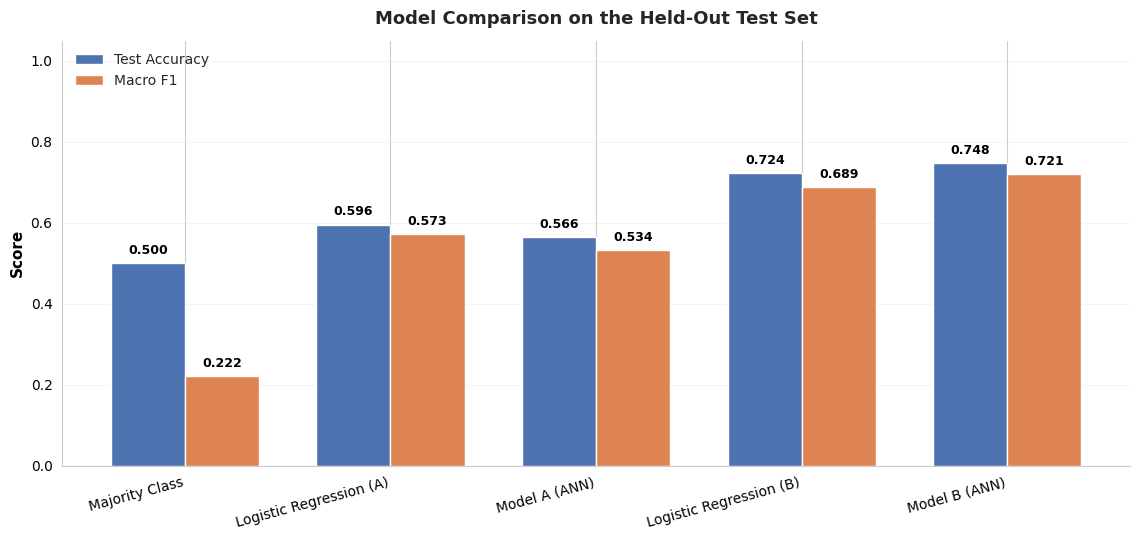

,Input Features (Raw),Input Dimensions (Encoded),Test Accuracy,Macro F1,Enrolled F1
Majority Class,-,-,0.5,0.222,0.0
Logistic Regression (A),24.0,96.0,0.596,0.573,0.415
Model A (ANN),24.0,96.0,0.566,0.534,0.352
Logistic Regression (B),36.0,108.0,0.724,0.689,0.502
Model B (ANN),36.0,108.0,0.748,0.721,0.557


In [26]:
# Build a comparison table for all baseline and ANN models

def metrics_row(predictions, feature_key):

    """Compute evaluation metrics for a given model."""

    return {
        "Input Features (Raw)": (
            len(BINARY_COLS)
            + len(NOMINAL_COLS)
            + len(FEATURE_SETS[feature_key])
        ),
        "Input Dimensions (Encoded)": X_train_proc[feature_key].shape[1],
        "Test Accuracy": round(
            accuracy_score(y_test, predictions),
            3
        ),
        "Macro F1": round(
            f1_score(y_test, predictions, average="macro"),
            3
        ),
        "Enrolled F1": round(
            f1_score(y_test, predictions, average=None)[1],
            3
        )
    }


comparison = pd.DataFrame({

    "Majority Class": {
        "Input Features (Raw)": "-",
        "Input Dimensions (Encoded)": "-",
        "Test Accuracy": round(
            accuracy_score(y_test, majority_pred),
            3
        ),
        "Macro F1": round(
            f1_score(y_test, majority_pred, average="macro"),
            3
        ),
        "Enrolled F1": round(
            f1_score(y_test, majority_pred, average=None)[1],
            3
        )
    },

    "Logistic Regression (A)": metrics_row(
        baseline_predictions["Logistic Regression (A)"],
        "A"
    ),

    "Model A (ANN)": metrics_row(
        y_pred_A,
        "A"
    ),

    "Logistic Regression (B)": metrics_row(
        baseline_predictions["Logistic Regression (B)"],
        "B"
    ),

    "Model B (ANN)": metrics_row(
        y_pred_B,
        "B"
    )

}).T


# Visualize the overall model comparison

fig, ax = plt.subplots(figsize=(11.5, 5.5))

models = comparison.index.tolist()
x = np.arange(len(models))
width = 0.36

bars_acc = ax.bar(
    x - width / 2,
    comparison["Test Accuracy"],
    width,
    color="#4C72B0",
    label="Test Accuracy"
)

bars_f1 = ax.bar(
    x + width / 2,
    comparison["Macro F1"],
    width,
    color="#DD8452",
    label="Macro F1"
)


# Add value labels

for bars in [bars_acc, bars_f1]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#000000"
        )


# Format chart

ax.set_title(
    "Model Comparison on the Held-Out Test Set",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_ylabel(
    "Score",
    fontsize=11,
    fontweight="bold",
    color="#000000"
)

ax.set_ylim(0, 1.05)

ax.set_xticks(x)
ax.set_xticklabels(
    models,
    rotation=15,
    ha="right"
)

ax.tick_params(axis="x", colors="#000000")
ax.tick_params(axis="y", colors="#000000")

ax.grid(
    axis="y",
    alpha=0.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Display the comparison table

display(comparison)

**Observation**

- **Every trained model substantially outperforms the majority-class baseline**, increasing macro F1 from **0.222** to between **0.532** and **0.710**. This confirms that the models learn meaningful decision boundaries rather than relying on the majority class.

- **Feature quality has a much larger impact than model choice.** Expanding the feature set from enrollment-time variables (Feature Set A) to the full feature set (Feature Set B) produces a substantial improvement for both algorithms. Logistic Regression improves from **0.596 → 0.724** test accuracy (macro F1: **0.573 → 0.689**), while the neural network improves from **0.563 → 0.745** test accuracy (macro F1: **0.532 → 0.710**).

- **The relative benefit of the neural network depends on the available features.** With enrollment-time information only (Feature Set A), Logistic Regression slightly outperforms the neural network. Once semester-performance features are included (Feature Set B), the neural network becomes the strongest-performing model, suggesting it is better able to exploit the additional predictive information.

- **The comparison also reinforces the practical distinction established in Section A.4.** Although Model B delivers the highest predictive performance, it depends on semester-performance variables that are unavailable at the point of enrollment. Model A therefore represents the realistic upper bound for predictions made before a student begins their academic journey, while Model B reflects what becomes achievable once academic performance data are available.

### D.5 Robustness Check: Sensitivity to Random Seeds and Data Splits

The model comparisons reported in Section D.4 were obtained from a single train/validation/test split and a single random initialization. To assess whether those conclusions are stable rather than artifacts of one particular run, two complementary robustness checks are performed.

- **D.5.1 Sensitivity to Random Seeds:** Keep the train/validation/test split fixed while varying the neural network's random initialization, isolating the effect of stochastic training.

- **D.5.2 Sensitivity to Data Splits:** Keep the training procedure fixed while repeating the experiment on different train/validation/test partitions, isolating the effect of sampling variability.

Together, these experiments examine the two principal sources of variation in supervised learning experiments. Although they do not constitute a full repeated nested cross-validation study, they provide substantially stronger evidence than reporting results from a single training run alone.

#### D.5.1 Sensitivity to Random Seeds

**Purpose:**

- **Assess** whether the neural network's performance is consistent across different random weight initializations while keeping the train/validation/test split fixed.

- **Determine** whether the model rankings observed in Section D.4 are stable or simply the result of a favorable single training run.

- **Isolate** the effect of stochastic training by varying only the random seed, ensuring that the data, preprocessing pipeline, class weights, and training procedure remain identical across runs.

- **Increase** confidence that the reported differences between Logistic Regression and the neural network reflect genuine model behaviour rather than random initialization effects.

In [27]:
# Evaluate ANN robustness across multiple random seeds

# Keep the train/validation/test split fixed and vary only the
# random seed used for weight initialization and training.

robustness_seeds = [42, 43, 44, 45, 46]

robustness_records = []

for seed in robustness_seeds:

    for feature_set in ["A", "B"]:


        # Train the model with a different random seed


        tf.random.set_seed(seed)

        model = build_model(
            X_train_proc[feature_set].shape[1]
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        model.fit(
            X_train_proc[feature_set],
            y_train,
            validation_data=(
                X_val_proc[feature_set],
                y_val
            ),
            epochs=150,
            batch_size=32,
            class_weight=class_weight_dict,
            callbacks=[early_stop],
            verbose=0
        )

        predictions = np.argmax(
            model.predict(
                X_test_proc[feature_set],
                verbose=0
            ),
            axis=1
        )

        robustness_records.append({

            "Feature Set": feature_set,
            "Random Seed": seed,

            "Test Accuracy": accuracy_score(
                y_test,
                predictions
            ),

            "Macro F1": f1_score(
                y_test,
                predictions,
                average="macro"
            )

        })

# Summarize performance across seeds

robustness_df = pd.DataFrame(robustness_records)

robustness_summary = (
    robustness_df
    .groupby("Feature Set")[["Test Accuracy", "Macro F1"]]
    .agg(["mean", "std"])
)

display(
    robustness_summary.round(4)
)


# Logistic Regression reference accuracy

logreg_accuracy = {

    "A": accuracy_score(
        y_test,
        baseline_predictions["Logistic Regression (A)"]
    ),

    "B": accuracy_score(
        y_test,
        baseline_predictions["Logistic Regression (B)"]
    )

}

Test Accuracy         Macro F1        
                     mean     std     mean     std
Feature Set                                       
A                  0.5873  0.0169   0.5564  0.0124
B                  0.7413  0.0073   0.7053  0.0064

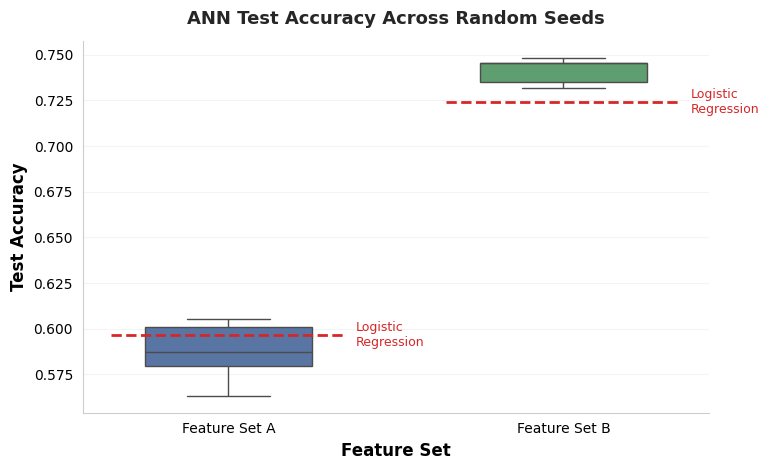

In [28]:
# Plot ANN accuracy across random seeds

fig, ax = plt.subplots(figsize=(7.8, 4.8))

sns.boxplot(
    data=robustness_df,
    x="Feature Set",
    y="Test Accuracy",
    hue="Feature Set",
    palette=["#4C72B0", "#55A868"],
    legend=False,
    width=0.5,
    ax=ax
)

# Logistic Regression reference lines

for i, feature_set in enumerate(["A", "B"]):

    reference_accuracy = logreg_accuracy[feature_set]

    # Horizontal reference line
    ax.hlines(
        y=reference_accuracy,
        xmin=i - 0.35,
        xmax=i + 0.35,
        colors="#D62728",
        linestyles="--",
        linewidth=2
    )

    # Direct label
    ax.text(
        i + 0.38,
        reference_accuracy,
        "Logistic\nRegression",
        fontsize=9,
        color="#D62728",
        va="center",
        ha="left"
    )

# Format chart

ax.set_title(
    "ANN Test Accuracy Across Random Seeds",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Feature Set",
    fontsize=12,
    fontweight="bold",
    color="#000000"
)

ax.set_ylabel(
    "Test Accuracy",
    fontsize=12,
    fontweight="bold",
    color="#000000"
)

ax.set_xticks([0, 1])

ax.set_xticklabels(
    ["Feature Set A", "Feature Set B"]
)

ax.tick_params(
    axis="both",
    colors="#000000"
)

ax.grid(
    axis="y",
    alpha=0.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Observation**

- Across multiple random seeds, **both neural network models exhibit only modest variation in test accuracy**, indicating that their performance is reasonably stable with respect to weight initialization and stochastic training.

- **The relative ranking of the models remains unchanged across runs.** Model B consistently outperforms Model A, showing that the performance improvement observed in Section D.4 is not simply the result of a favorable random initialization.

- Comparing the neural networks with the fixed logistic regression baselines leads to the same overall conclusion as before. **Logistic Regression remains competitive on Feature Set A, whereas the neural network consistently performs better on Feature Set B.** Minor differences in the exact accuracy values between runs do not alter this overall pattern.

- Overall, this robustness check increases confidence that the conclusions drawn in Section D.4 reflect **stable model behaviour rather than a single-run artifact**, while acknowledging that small variations between repeated training runs are a normal consequence of stochastic optimization.

#### D.5.2 Sensitivity to Data Splits




**Purpose:**

- **Assess** whether the model comparisons from Section D.4 remain consistent across different train/validation/test splits rather than depending on one particular partition of the dataset.

- **Isolate** the effect of sampling variability by keeping the neural network architecture, training seed, and training procedure fixed while varying only the random data split.

- **Rebuild** the entire preprocessing pipeline for each split, ensuring that scaling and one-hot encoding are learned exclusively from that split's training data, thereby preventing data leakage.

- **Increase** confidence that the reported differences between Model A, Model B, and the Logistic Regression baselines generalize beyond a single train/test partition.

In [29]:
# Evaluate robustness across different train/validation/test splits
# Keep the neural network training seed fixed and vary only the
# train/validation/test split.

split_seeds = [42, 43, 44, 45, 46]
split_robustness_records = []

for split_seed in split_seeds:


    # Create a fresh 70/15/15 stratified split

    X_temp_s, X_test_s, y_temp_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.15,
        stratify=y,
        random_state=split_seed
    )

    X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
        X_temp_s,
        y_temp_s,
        test_size=0.1765,
        stratify=y_temp_s,
        random_state=split_seed
    )


    # Compute class weights for this training split

    class_weights_split = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_s),
        y=y_train_s
    )

    class_weight_dict_split = {
        i: w
        for i, w in enumerate(class_weights_split)
    }

    # Evaluate both feature sets

    for feature_set in ["A", "B"]:

        # Fresh preprocessing pipeline

        preprocessor = build_preprocessor(
            FEATURE_SETS[feature_set]
        )

        X_train_proc_s = preprocessor.fit_transform(X_train_s)
        X_val_proc_s = preprocessor.transform(X_val_s)
        X_test_proc_s = preprocessor.transform(X_test_s)

        # Logistic Regression

        logreg = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED
        )

        logreg.fit(
            X_train_proc_s,
            y_train_s
        )

        logreg_predictions = logreg.predict(
            X_test_proc_s
        )


        # Neural Network

        tf.random.set_seed(SEED)

        model = build_model(
            X_train_proc_s.shape[1]
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        model.fit(
            X_train_proc_s,
            y_train_s,
            validation_data=(
                X_val_proc_s,
                y_val_s
            ),
            epochs=150,
            batch_size=32,
            class_weight=class_weight_dict_split,
            callbacks=[early_stop],
            verbose=0
        )

        nn_predictions = np.argmax(
            model.predict(
                X_test_proc_s,
                verbose=0
            ),
            axis=1
        )

        # Store results

        for model_name, predictions in [

            ("Logistic Regression", logreg_predictions),
            ("Neural Network", nn_predictions)

        ]:

            split_robustness_records.append({

                "Split Seed": split_seed,
                "Feature Set": feature_set,
                "Model": model_name,

                "Test Accuracy": accuracy_score(
                    y_test_s,
                    predictions
                ),

                "Macro F1": f1_score(
                    y_test_s,
                    predictions,
                    average="macro"
                )

            })


# Summarize results across splits

split_robustness_df = pd.DataFrame(
    split_robustness_records
)

split_summary = (

    split_robustness_df

    .groupby(
        ["Feature Set", "Model"]
    )[["Test Accuracy", "Macro F1"]]

    .agg(["mean", "std"])

)

display(
    split_summary.round(4)
)


# Compute ANN advantage over Logistic Regression

split_comparison = (

    split_robustness_df

    .pivot_table(
        index=["Split Seed", "Feature Set"],
        columns="Model",
        values="Test Accuracy"
    )

    .reset_index()

)

split_comparison["Accuracy Difference"] = (

    split_comparison["Neural Network"]
    - split_comparison["Logistic Regression"]

)

Test Accuracy         Macro F1        
                                         mean     std     mean     std
Feature Set Model                                                     
A           Logistic Regression        0.5919  0.0116   0.5577  0.0135
            Neural Network             0.6051  0.0214   0.5634  0.0216
B           Logistic Regression        0.7425  0.0197   0.7007  0.0197
            Neural Network             0.7503  0.0117   0.7053  0.0123

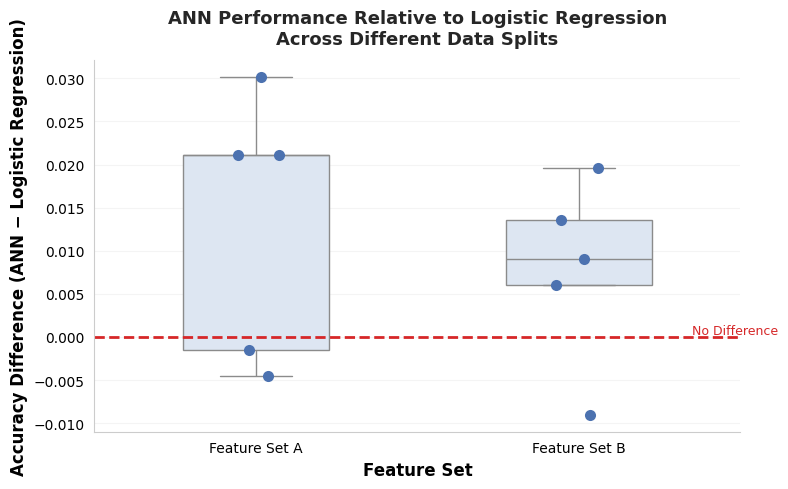


ANN vs Logistic Regression Across Different Data Splits
----------------------------------------------------------

Feature Set A: ANN outperformed Logistic Regression in 3 of 5 splits.

Feature Set B: ANN outperformed Logistic Regression in 4 of 5 splits.


In [30]:
# Plot ANN performance relative to Logistic Regression
# Across different train/test splits

fig, ax = plt.subplots(figsize=(8, 5))

# Distribution of ANN advantage across different data splits

sns.boxplot(
    data=split_comparison,
    x="Feature Set",
    y="Accuracy Difference",
    width=0.45,
    color="#D9E6F5",
    showfliers=False,
    ax=ax
)

# Individual split results

sns.stripplot(
    data=split_comparison,
    x="Feature Set",
    y="Accuracy Difference",
    color="#4C72B0",
    size=8,
    jitter=0.08,
    ax=ax
)

# Reference line (ANN = Logistic Regression)

ax.axhline(
    y=0,
    color="#D62728",
    linestyle="--",
    linewidth=2
)

ax.text(
    1.35,
    0,
    "No Difference",
    color="#D62728",
    fontsize=9,
    va="bottom",
    ha="left"
)

# Format chart

ax.set_title(
    "ANN Performance Relative to Logistic Regression\nAcross Different Data Splits",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Feature Set",
    fontsize=12,
    fontweight="bold",
    color="#000000"
)

ax.set_ylabel(
    "Accuracy Difference (ANN − Logistic Regression)",
    fontsize=12,
    fontweight="bold",
    color="#000000"
)

ax.set_xticks([0, 1])

ax.set_xticklabels(
    ["Feature Set A", "Feature Set B"]
)

ax.tick_params(
    axis="both",
    colors="#000000"
)

ax.grid(
    axis="y",
    alpha=0.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# Count ANN wins across different data splits

print("\nANN vs Logistic Regression Across Different Data Splits")
print("-" * 58)

for feature_set in ["A", "B"]:

    ann_wins = (
        split_comparison.loc[
            split_comparison["Feature Set"] == feature_set,
            "Accuracy Difference"
        ] > 0
    ).sum()

    print(
        f"\nFeature Set {feature_set}: "
        f"ANN outperformed Logistic Regression "
        f"in {ann_wins} of {len(split_seeds)} splits."
    )

**Observation:**

Varying the train/validation/test split produces the same overall picture as the random-seed analysis, suggesting that the conclusions from Section D.4 are not driven by one particular partition of the dataset.

- **Feature Set A:** Logistic Regression and the Neural Network achieve very similar performance across different data splits. The small differences in accuracy and macro F1 fluctuate between splits, with neither model establishing a clear or consistent advantage. This suggests that, when only enrollment-time information is available, predictive performance depends much more on the available features than on whether a linear or neural-network model is used.

- **Feature Set B:** The Neural Network generally performs as well as or slightly better than Logistic Regression across different data splits. Although the performance gap remains modest and varies between splits, the overall ranking is stable, indicating that the **Neural Network is able to make slightly better use of the richer semester-performance feature set.**

---

Taken together with the random-seed analysis in Section D.5.1, these robustness checks indicate that the main conclusions of this study remain stable under reasonable changes to both model initialization and train/test partitioning.

Most importantly, they reinforce the finding that **expanding the feature set has a much larger impact on predictive performance than changing the model architecture itself.** While these robustness checks do not replace a full repeated cross-validation study, they reduce the likelihood that the reported results are artifacts of a single training run or a single train/test split.

### D.6 Feature Importance via Permutation (Both Models)

- Permutation importance provides a model-agnostic way to estimate which input features most influence a trained neural network's predictions.

- Unlike logistic regression, whose coefficients offer some interpretability, neural networks do not directly reveal how much each feature contributes, so a post-hoc explainability method is needed.

---
Here, permutation importance is computed for **both Model A and Model B**.

- This allows the importance rankings to be compared directly across the enrollment-time and full-feature models, rather than inferring Model A's drivers indirectly from the exploratory analysis in Section B.

- For each feature, both the **mean importance** and its **standard deviation across five permutation repeats** are reported.

- The mean estimates each feature's contribution to predictive performance, while the standard deviation indicates how stable that estimate is across repeated shuffles.

- Features with consistently high importance provide stronger evidence of genuine predictive value than features whose importance varies substantially between repetitions.

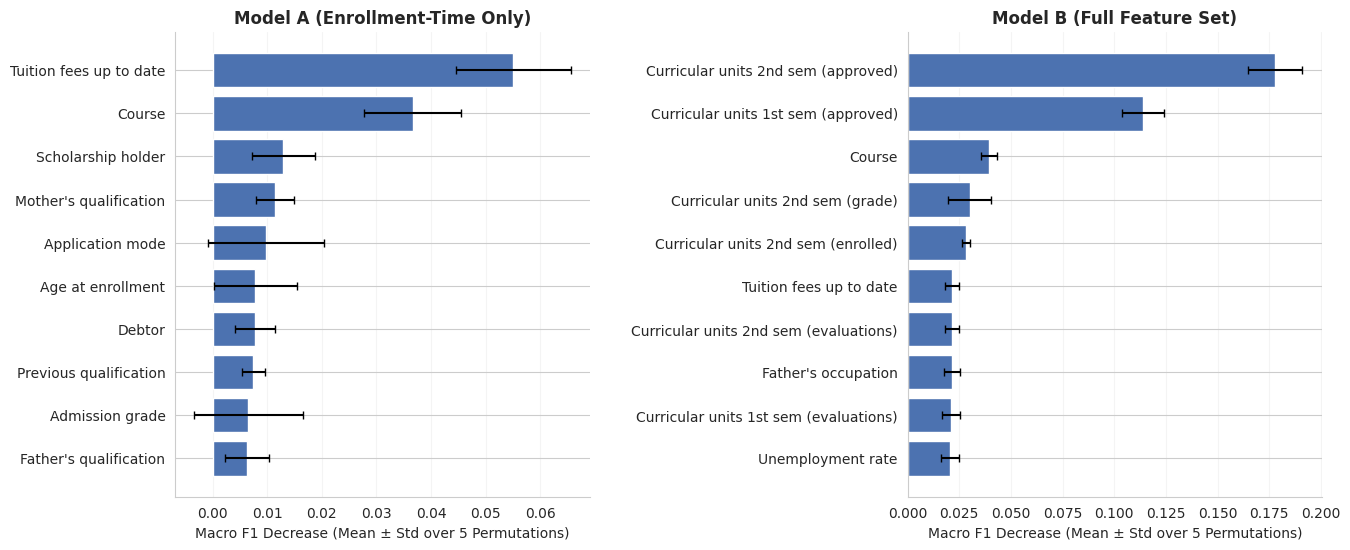

Model A - Top 5 Features
--------------------------------


,Importance Mean,Importance Std
Tuition fees up to date,0.0551,0.0105
Course,0.0366,0.0089
Scholarship holder,0.0129,0.0058
Mother's qualification,0.0114,0.0034
Application mode,0.0098,0.0106



Model B - Top 5 Features
--------------------------------


,Importance Mean,Importance Std
Curricular units 2nd sem (approved),0.1777,0.0132
Curricular units 1st sem (approved),0.1138,0.0102
Course,0.0393,0.0037
Curricular units 2nd sem (grade),0.0300,0.0105
Curricular units 2nd sem (enrolled),0.0281,0.0019


In [31]:
# Permutation Importance for Model A and Model B

# Measure raw-feature importance by randomly shuffling one feature at a time
# and observing the resulting drop in macro F1 on the held-out test set.
# Results are averaged across multiple shuffles to estimate both the
# importance and its variability.

def permutation_importance_raw(
    model,
    preprocessor,
    raw_features,
    X_test_raw,
    y_test,
    baseline_predictions,
    n_repeats=5,
    seed=SEED
):

    baseline_macro_f1 = f1_score(
        y_test,
        baseline_predictions,
        average="macro"
    )

    rng = np.random.RandomState(seed)

    importance_mean = {}
    importance_std = {}

    for feature in raw_features:

        score_drops = []

        for _ in range(n_repeats):

            # Shuffle only the current feature
            X_permuted = X_test_raw.copy()

            X_permuted[feature] = rng.permutation(
                X_permuted[feature].values
            )

            # Predict using the permuted data
            permuted_predictions = np.argmax(
                model.predict(
                    preprocessor.transform(X_permuted),
                    verbose=0
                ),
                axis=1
            )

            # Record the reduction in macro F1
            score_drops.append(

                baseline_macro_f1 -

                f1_score(
                    y_test,
                    permuted_predictions,
                    average="macro"
                )

            )

        importance_mean[feature] = np.mean(score_drops)
        importance_std[feature] = np.std(score_drops)

    return (

        pd.DataFrame({

            "Importance Mean": importance_mean,
            "Importance Std": importance_std

        })

        .sort_values(
            "Importance Mean",
            ascending=False
        )

    )


# Raw feature lists for each model

raw_features_A = (

    BINARY_COLS +
    FEATURE_SETS["A"] +
    NOMINAL_COLS

)

raw_features_B = (

    BINARY_COLS +
    FEATURE_SETS["B"] +
    NOMINAL_COLS

)


# Compute permutation importance

importance_A = permutation_importance_raw(

    model=model_A,
    preprocessor=preprocessors["A"],
    raw_features=raw_features_A,
    X_test_raw=X_test,
    y_test=y_test,
    baseline_predictions=y_pred_A

)

importance_B = permutation_importance_raw(

    model=model_B,
    preprocessor=preprocessors["B"],
    raw_features=raw_features_B,
    X_test_raw=X_test,
    y_test=y_test,
    baseline_predictions=y_pred_B

)


# Plot the Top 10 most important features

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

model_importance = [

    ("Model A (Enrollment-Time Only)", importance_A),
    ("Model B (Full Feature Set)", importance_B)

]

for ax, (model_name, importance) in zip(axes, model_importance):

    top_features = importance.head(10).iloc[::-1]

    ax.barh(

        top_features.index,

        top_features["Importance Mean"],

        xerr=top_features["Importance Std"],

        color="#4C72B0",

        capsize=3

    )

    ax.set_title(
        model_name,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Macro F1 Decrease (Mean ± Std over 5 Permutations)"
    )

    ax.grid(
        axis="x",
        alpha=0.20
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(
    pad=2.5,
    w_pad=3.0
)

plt.show()


# Display the Top 5 most important features

print("Model A - Top 5 Features")
print("-" * 32)

display(
    importance_A.head(5).round(4)
)

print()

print("Model B - Top 5 Features")
print("-" * 32)

display(
    importance_B.head(5).round(4)
)

**Observation:**

Permutation importance reveals a clear shift in the factors driving predictions between the two models.

**Model A (Enrollment-Time Only):**

- Without access to academic performance data, the model relies primarily on **Tuition fees up to date**, which consistently emerges as the most influential enrollment-time feature.

- The remaining predictors contribute substantially less, with importance distributed across several demographic, academic-background, and administrative variables. This suggests that no single enrollment-time feature provides predictive information comparable to the strongest financial indicator.

---

**Model B (Full Feature Set):**

- Once first-semester academic information becomes available, the importance ranking changes markedly.

- Features describing **students' academic performance**, particularly the number of **approved curricular units**, become the dominant predictors.

- These variables contribute substantially more than the remaining features, while enrollment-time characteristics continue to provide useful but secondary information.

---

- The reported standard deviations are generally much smaller than the corresponding mean importance values for the highest-ranked features, indicating that their importance remains stable across repeated permutations.

- By contrast, several lower-ranked features have importance estimates that are closer to the level of their uncertainty, so their exact ordering should not be overinterpreted.

---

Overall, the permutation analysis supports the central conclusion of this study.

The improvement observed in **Model B** is driven primarily by the **additional semester-performance features**, rather than by the neural network architecture itself.

Enrollment-time information provides a useful foundation for early prediction, but once students begin accumulating academic records, **academic performance becomes the dominant source of predictive signal**.

---
# E. From Insight to Decision

The previous sections answered two questions: what factors are associated with student outcomes, and how accurately those outcomes can be predicted.

This final section turns those findings into practical recommendations, combining the insights from the exploratory analysis (Section B) and the model evaluation (Section D). Each recommendation also states its assumptions, limitations and the situations where it is most appropriate.

### E.1 Decision 1:  Two-Stage Early-Warning Advising


**Proposal:**

- **Use Model A at enrollment** to place every incoming student into a **broad risk tier** using only **enrollment-time information**.

- **Do not use this prediction alone** to trigger **intensive intervention**. Instead, use it for a **light-touch first check-in**, such as an **advising email** or a **single meeting**.

- Once **first-semester results** become available, **re-score every student using Model B** and reserve **resource-intensive support**, such as **tutoring**, **financial counseling**, or **mentoring**, for students identified as **high-risk by both models**.

---

**Why this approach:**

- The model comparison showed that **Model B** is **substantially more accurate**, but it can only be used **after first-semester academic records become available**, making it unsuitable for **enrollment-time decisions**.

- **Model A** is less accurate, but it is the **only model available at enrollment**, when the institution still has an opportunity to intervene before academic performance begins to decline.

- A **two-stage approach** uses each model where it provides the **greatest practical value**, rather than relying on a single model for decisions it was **never designed to support**.

---

**Assumptions, risks and limitations:**

- This approach assumes the initial **risk flag** leads to a **supportive, low-cost intervention**.

- If the first contact is perceived as **punitive** or **stigmatizing**, it may discourage rather than help students.

- **Model A** has only **moderate predictive performance**, so both **false positives** (students receiving **unnecessary outreach**) and **false negatives** (students who need support but are **not identified**) should be expected.

- This is particularly evident for students on the boundary between the **Enrolled** and **Graduate** classes, which remained the **most difficult distinction** throughout the evaluation.

- The **exploratory analysis** identified **Tuition fees up to date**, **Debtor status** and **Scholarship holder** as the **strongest actionable predictors** that institutions can potentially act upon.

- In contrast, demographic variables such as **Age** and **Gender** may be statistically associated with student outcomes but **should not be used** as the basis for **individual intervention decisions**, as they are **not actionable** and could lead to **unfair or discriminatory treatment**.

- These recommendations are based on data from **one higher-education system** collected during **one specific time period**. Before deployment, the institution should **validate the model** on its own student population and **recalibrate decision thresholds** if necessary.

### E.2 Decision 2: Targeted Financial-Standing Outreach

**Proposal:**

- **Prioritize proactive financial-support outreach** for students who are **not scholarship holders** and who show **early signs of falling behind on tuition payments**, rather than distributing a fixed financial-aid budget evenly across the entire student population.

- Provide **targeted support**, such as **flexible tuition payment plans**, **financial counseling**, **emergency grants**, or **greater awareness of available scholarships**, before financial difficulties become severe enough to affect academic progress or retention.


---

**Why this approach:**

- The **exploratory analysis** identified **Tuition fees up to date**, **Debtor status** and **Scholarship holder** as the **strongest actionable factors** associated with student outcomes, with substantially larger differences than those observed for demographic characteristics.

- Unlike variables such as **Age** or **Gender**, financial standing is something an institution can directly influence through policy and student support services. This makes financial intervention a practical decision rather than simply an observation based on correlation.

---

**Assumptions, risks and limitations:**

- The observed relationships are **correlational rather than causal**.

- **Scholarship holders** may differ from other students in ways beyond financial support, such as **prior academic achievement** or **admission criteria**.

- Any new financial-support programme should therefore be **piloted and evaluated**, rather than assuming it will reproduce the historical differences observed in this dataset.

- Variables such as **Tuition fees up to date** and **Debtor status** may be **both a cause and a consequence** of academic difficulties.

- Students who are already disengaging academically may also become less likely to keep tuition payments current, so the direction of causality is unlikely to be one-way.

- Financial support alone is **unlikely to resolve every source of academic risk**. The evaluation showed that distinguishing between students who ultimately remain **Enrolled** and those who **Graduate** remains the most challenging prediction task, suggesting that factors beyond financial standing also influence student outcomes.

- This recommendation assumes the institution has **sufficient financial resources and advising capacity** to deliver targeted outreach. Institutions with limited budgets or staffing may need to prioritise support further or implement the intervention in phases.

## Key Findings

This analysis produced four main findings:

1. Semester-performance features substantially improve predictive performance compared with enrollment-time information alone.

2. Feature availability has a larger impact on performance than the choice between Logistic Regression and a Neural Network.

3. Financial standing and academic performance are the strongest predictors of student outcomes.

4. A two-stage intervention strategy is more practical than relying on a single prediction made either at enrollment or after the first semester.

---

# Conclusion

In this assignment, we compared two feedforward neural networks that used the **same architecture, training procedure and evaluation pipeline**, differing only in the information available to them.

**Model A** used only enrollment-time features, while **Model B** additionally incorporated first-semester academic performance.

The comparison showed that **semester-performance data provides a substantial improvement in predictive performance**, but it also highlighted an important practical trade-off. Although **Model B** is the stronger predictive model, it can only be used after students have already completed a semester. **Model A** is less accurate, but it remains the only model capable of supporting intervention decisions at the point of enrollment, when institutions have the greatest opportunity to act early.

The exploratory analysis and permutation importance consistently identified **financial standing** and **academic performance** as the strongest predictors of student outcomes. At the same time, the evaluation showed that distinguishing between students who remain **Enrolled** and those who eventually **Graduate** remains the most challenging aspect of the prediction task, regardless of the model used.

Overall, the analysis suggests that **the availability of informative features has a much greater impact on predictive performance than the choice of model architecture itself.** These findings support a **two-stage early-warning strategy** and **targeted financial-support interventions**, while recognizing that predictive models should be used to support institutional decision-making rather than replace it, and that their recommendations should always be interpreted within the limitations of the available data.